# 📊 **Brazilian Cities - Análise Exploratória de Dados**
> **Projeto Interdisciplinar para Sistemas de Informação 3 - UFRPE 2026.1**
*   👥**Autores**: Arthur Barbosa, Danielly Nunes, Gabriel Sabino, Isadora Morais, Luiz Vinicius
*   🗓️**Período**: 2026.1
*   🔗**Repositório**: https://github.com/IsadoraMoraiss/Project_Pisi3.git
*   🎲**Dataset**: https://www.kaggle.com/datasets/crisparada/brazilian-cities
*   🎯**Objetivo**: Realizar uma Análise Exploratória de Dados (EDA) sobre o dataset Brazilian Cities, investigando padrões socioeconômicos, demográficos e de infraestrutura dos municípios brasileiros, com foco na identificação de destinos com potencial turístico subexplorado.









---


## 🚀 Sobre este Projeto:

Este notebook documenta a **Análise Exploratória de Dados (EDA)** do dataset *Brazilian Cities*, disponível no Kaggle, desenvolvida como parte do projeto *Brasil em Foco* na disciplina PISI 3 da UFRPE.

O Brasil possui mais de **5.500 municípios** com realidades socioeconômicas extremamente distintas. Apesar do enorme potencial turístico nacional, a atividade concentra-se historicamente em poucos polos consolidados. Este projeto busca **identificar destinos com bons indicadores, mas baixa visibilidade turística**.

### Etapas deste Notebook

| # | Etapa | Descrição |
|---|-------|-----------|
| 1 | 📥 Carregamento | Inspeção inicial — sanity check |
| 2 | 🧹 Limpeza | Nulos, duplicatas e padronização |
| 3 | 🔍 Univariada | Análise de cada variável isoladamente |
| 4 | 🔗 Bivariada/Multivariada | Relações entre variáveis |
| 5 | 📦 Outliers | Identificação e interpretação |
| 6 | 💡 Síntese | Hipóteses e próximos passos |

---
## 🗺️ Contexto do Problema:

Como analistas de dados no projeto *Brasil em Foco*, faremos parte da análise de **potencial turístico de cidades brasileiras**.
O desafio é **coletar, tratar e analisar os dados**, utilizando Python e suas principais bibliotecas para extrair insights valiosos.
A partir desta análise, a equipe poderá avançar para modelos preditivos e desenvolver estratégias de recomendação.

### 🎯 Perguntas de Negócio (EDA)

> Estas perguntas **guiam diretamente a exploração dos dados** nas Fases 3 e 4.
> Cada gráfico produzido responde, total ou parcialmente, a uma destas questões.



- #### P1 — Infraestrutura: **"Quais municípios possuem uma infraestrutura de serviços (`comp_i`) desproporcional ao seu tamanho populacional, indicando um polo econômico ou turístico?"** -> Respondida por: *Fase 3.4 · Fase 4.2*



- #### P2 — Custo-Benefício: **"Existe relação direta entre o custo de vida estimado (`gdp_capita`) e a qualidade da infraestrutura turística (`hotels`, `beds`)?"** -> Respondida por: *Fase 4.1 · Fase 4.2*



- #### P3 — Conectividade: **"A presença do Uber está concentrada apenas em capitais ou já atingiu cidades com alto potencial turístico no interior?"**   -> Respondida por: *Fase 3.5*



- #### P4 — Oportunidade ("Joias Escondidas"): **"Quais cidades apresentam alto IDH, mas baixa densidade de leitos por habitante (`leitos_por_hab`), representando destinos subexplorados com alto potencial?"** -> Respondida por: *Fase 4.5 — gráfico dos quadrantes*




---
## 📖 Dicionário de Dados:

Principais variáveis do dataset **Brazilian Cities** utilizadas nesta análise:


### 🧑‍🤝‍🧑 Identificação e Localização
- `CITY`: Nome do município
- `STATE`: Unidade Federativa (UF)

### 👥 Dados Demográficos
- `IBGE_RES_POP`: População residente total
- `IBGE_RES_POP_BRAS`: População brasileira residente
- `IBGE_1` a `IBGE_60_M` / `IBGE_60_F`: Faixas etárias (% da população) — usadas para perfil jovem vs. idoso

### 💰 Indicadores Econômicos
- `GDP`: Produto Interno Bruto total (R$)
- `GDP_CAPITA`: PIB per capita (R$) — **principal proxy de custo de vida**
- `IDHM`: Índice de Desenvolvimento Humano Municipal

### 🏨 Infraestrutura Turística
- `HOTELS`: Número de hotéis e meios de hospedagem
- `BEDS`: Número de leitos disponíveis

### 🏗️ Infraestrutura de Serviços
- `COMP_I`: Empresas ativas nos setores de alojamento e alimentação
- `UBER`: Disponibilidade de Uber no município *(1 = sim, 0 = não)*
- `BANCO_AG` / `BANCO_PA`: Agências bancárias públicas e privadas

### 🌿 Turismo e Território
- `IBGE_PLANTED_AREA`: Área plantada (ha)
- `AREA`: Área territorial total do município (km²)

> ⚠️ **Nota:** Os nomes das colunas foram padronizados para **letras minúsculas e sem caracteres especiais** durante a fase de limpeza, seguindo boas práticas de legibilidade e consistência no código.

---
## 📥 Fase 1 — Carregamento e Inspeção Inicial (Sanity Check)

Antes de qualquer análise, precisamos **entender a estrutura do dataset**:
quantas linhas e colunas existem, quais os tipos de dados, se há valores ausentes e como os dados se apresentam.

### 1.1 Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


### 1.2 Carregamento do Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/brazilian_cities/BRAZIL_CITIES.csv", sep=';', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.3 Entendendo o Dataset

In [ ]:
print('1️⃣ Primeiras Linhas: ')
display(df.head())

print('\n 2️⃣ Informações Gerais: ')
df.info()

print('\n 3️⃣ Nomes das Colunas: ')
print(df.columns.tolist())

print('\n 4️⃣ Dimensão do DataFrame: ')
print(f"O DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

print('\n 5️⃣ Estatísticas Descritivas: ')
display(df.describe().T.round(2))

print('\n 6️⃣ Contagem de Valores Únicos por Coluna: ')
display(df.nunique())

print('\n 7️⃣ Valores Ausentes por Coluna: ')
display(df.isnull().sum())

print('\n 8️⃣ Tipos de Dados por Coluna: ')
display(df.dtypes)

print('\n 9️⃣ Análise das colunas que possuem tipo de dado ''object'': ')
object_cols = df.select_dtypes(include='object').columns

print("Colunas do tipo 'object':")
for col in object_cols:
    print(f"- {col}")
    # Para colunas com poucos valores únicos, mostrar value_counts
    if df[col].nunique() < 50:
        print(f"  Valores únicos e suas contagens em '{col}':")
        display(df[col].value_counts().head())
    else:
        print(f"  '{col}' possui {df[col].nunique()} valores únicos. Exibindo os primeiros 5:")
        display(df[col].head())
    # Inferir o tipo de dado para verificar se há misturas
    inferred_type = pd.api.types.infer_dtype(df[col], skipna=True)
    print(f"  Tipo de dado inferido para '{col}': {inferred_type}\n")

print('\n 🔟 Análise da coluna área: ')
# Verificação específica para a coluna 'AREA'
print('\n--- Verificação Detalhada da Coluna AREA ---')
print(f"Tipo atual da coluna 'AREA': {df['AREA'].dtype}")
print(f"Tipo de dado inferido para 'AREA': {pd.api.types.infer_dtype(df['AREA'], skipna=True)}")
print("Valores não-numéricos em 'AREA' (amostra):")
# Identificar e mostrar alguns valores que não são números após tentar limpar
area_cleaned = df['AREA'].astype(str).str.replace(',', '.', regex=False)
non_numeric_area = area_cleaned[pd.to_numeric(area_cleaned, errors='coerce').isna()]
if not non_numeric_area.empty:
    display(non_numeric_area.unique())
else:
    print('Nenhum valor não-numérico aparente após limpeza simples (substituição de vírgula por ponto).')

1️⃣ Primeiras Linhas: 


,CITY,STATE,CAPITAL,IBGE_RES_POP,IBGE_RES_POP_BRAS,IBGE_RES_POP_ESTR,IBGE_DU,IBGE_DU_URBAN,IBGE_DU_RURAL,IBGE_POP,...,Pu_Bank,Pr_Assets,Pu_Assets,Cars,Motorcycles,Wheeled_tractor,UBER,MAC,WAL-MART,POST_OFFICES
0,Abadia De GoiÃ¡s,GO,0,6876.0,6876.0,0.0,2137.0,1546.0,591.0,5300.0,...,NaN,NaN,NaN,2158.0,1246.0,0.0,NaN,NaN,NaN,1.0
1,Abadia Dos Dourados,MG,0,6704.0,6704.0,0.0,2328.0,1481.0,847.0,4154.0,...,NaN,NaN,NaN,2227.0,1142.0,0.0,NaN,NaN,NaN,1.0
2,AbadiÃ¢nia,GO,0,15757.0,15609.0,148.0,4655.0,3233.0,1422.0,10656.0,...,1.0,33724584.0,67091904.0,2838.0,1426.0,0.0,NaN,NaN,NaN,3.0
3,AbaetÃ©,MG,0,22690.0,22690.0,0.0,7694.0,6667.0,1027.0,18464.0,...,2.0,44974716.0,371922572.0,6928.0,2953.0,0.0,NaN,NaN,NaN,4.0
4,Abaetetuba,PA,0,141100.0,141040.0,60.0,31061.0,19057.0,12004.0,82956.0,...,4.0,76181384.0,800078483.0,5277.0,25661.0,0.0,NaN,NaN,NaN,2.0



 2️⃣ Informações Gerais: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 81 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CITY                    5573 non-null   object 
 1   STATE                   5573 non-null   object 
 2   CAPITAL                 5573 non-null   int64  
 3   IBGE_RES_POP            5565 non-null   float64
 4   IBGE_RES_POP_BRAS       5565 non-null   float64
 5   IBGE_RES_POP_ESTR       5565 non-null   float64
 6   IBGE_DU                 5563 non-null   float64
 7   IBGE_DU_URBAN           5563 non-null   float64
 8   IBGE_DU_RURAL           5492 non-null   float64
 9   IBGE_POP                5565 non-null   float64
 10  IBGE_1                  5565 non-null   float64
 11  IBGE_1-4                5565 non-null   float64
 12  IBGE_5-9                5565 non-null   float64
 13  IBGE_10-14              5565 non-null   float64
 14  IBGE_15-59   

,count,mean,std,min,25%,50%,75%,max
CAPITAL,5573.0,0.00,0.07,0.0,0.0,0.0,0.00,1.0
IBGE_RES_POP,5565.0,34277.77,203112.62,805.0,5235.0,10934.0,23424.00,11253503.0
IBGE_RES_POP_BRAS,5565.0,34200.27,201490.49,805.0,5230.0,10926.0,23390.00,11133776.0
IBGE_RES_POP_ESTR,5565.0,77.50,1795.88,0.0,0.0,0.0,10.00,119727.0
IBGE_DU,5563.0,10302.72,64776.71,239.0,1572.5,3174.0,6726.00,3576148.0
...,...,...,...,...,...,...,...,...
Wheeled_tractor,5562.0,5.75,55.38,0.0,0.0,0.0,1.00,3236.0
UBER,125.0,1.00,0.00,1.0,1.0,1.0,1.00,1.0
MAC,166.0,4.28,11.77,1.0,1.0,2.0,3.00,130.0
WAL-MART,102.0,2.06,3.39,1.0,1.0,1.0,1.75,26.0



 6️⃣ Contagem de Valores Únicos por Coluna: 


...

,count
RURAL_URBAN,
Rural Adjacente,3040
Urbano,1456
IntermediÃ¡rio Adjacente,686
Rural Remoto,323
IntermediÃ¡rio Remoto,60


  Tipo de dado inferido para 'RURAL_URBAN': string

- GVA_MAIN
  Valores únicos e suas contagens em 'GVA_MAIN':


,count
GVA_MAIN,
"AdministraÃ§Ã£o, defesa, educaÃ§Ã£o e saÃºde pÃºblicas e seguridade social",2725
Demais serviÃ§os,1477
"Agricultura, inclusive apoio Ã agricultura e a pÃ³s colheita",735
IndÃºstrias de transformaÃ§Ã£o,261
"PecuÃ¡ria, inclusive apoio Ã pecuÃ¡ria",161


  Tipo de dado inferido para 'GVA_MAIN': string


 🔟 Análise da coluna área: 

--- Verificação Detalhada da Coluna AREA ---
Tipo atual da coluna 'AREA': object
Tipo de dado inferido para 'AREA': string
Valores não-numéricos em 'AREA' (amostra):


array(['1.045.13', '1.817.07', '1.610.65', ..., '3.779.35', '5.079.66',
       '2.140.11'], dtype=object)

### 1.4 Mapeamento de Valores Nulos

Colunas com nulos: 78 de 81 total


,Qtd. Nulos,% do Total
WAL-MART,5471,98.17
UBER,5448,97.76
MAC,5407,97.02
HOTELS,4686,84.08
BEDS,4686,84.08
...,...,...
COMP_I,3,0.05
COMP_H,3,0.05
COMP_G,3,0.05
COMP_F,3,0.05


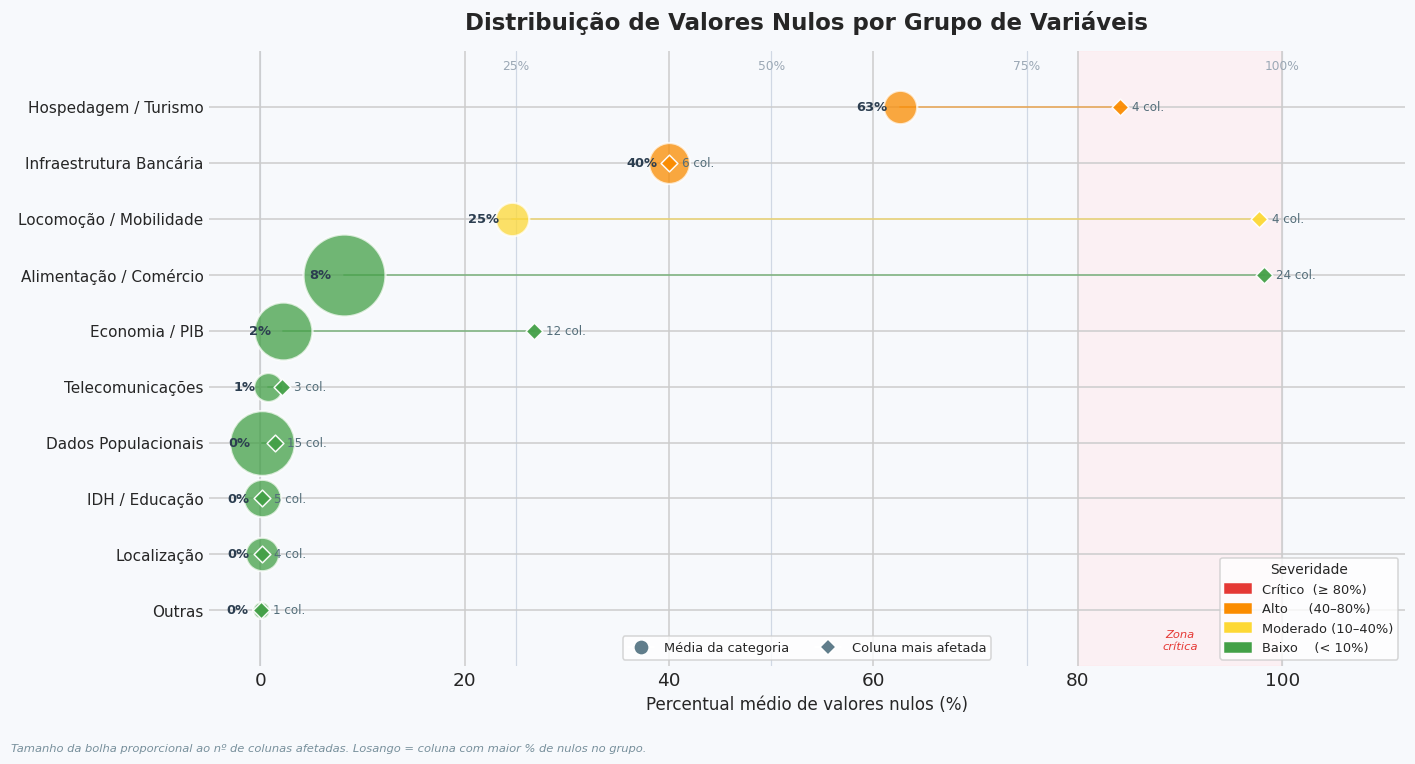

Fonte: elaborado pelos autores (2026).


In [ ]:
# Contagem e percentual de nulos por coluna
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)

resumo_nulos = (
    pd.DataFrame({'Qtd. Nulos': nulos, '% do Total': pct})
    .query('`Qtd. Nulos` > 0')
    .sort_values('% do Total', ascending=False)
)

print(f'Colunas com nulos: {len(resumo_nulos)} de {df.shape[1]} total')
display(resumo_nulos)

# Mapa visual de nulos: bubble chart agrupado por categoria
if not resumo_nulos.empty:
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D

    CATEGORIAS = {
        'Locomoção / Mobilidade':  ['UBER', 'Cars', 'Motorcycles', 'Wheeled_tractor'],
        'Alimentação / Comércio':  ['MAC', 'WAL-MART', 'COMP_G', 'COMP_H', 'COMP_I',
                                    'COMP_J', 'COMP_K', 'COMP_L', 'COMP_M', 'COMP_N',
                                    'COMP_O', 'COMP_P', 'COMP_Q', 'COMP_R', 'COMP_S',
                                    'COMP_T', 'COMP_U', 'COMP_A', 'COMP_B', 'COMP_C',
                                    'COMP_D', 'COMP_E', 'COMP_F', 'COMP_TOT'],
        'Hospedagem / Turismo':    ['HOTELS', 'BEDS', 'REGIAO_TUR', 'CATEGORIA_TUR'],
        'Telecomunicações':        ['PAY_TV', 'FIXED_PHONES', 'POST_OFFICES'],
        'Infraestrutura Bancária': ['Pr_Agencies', 'Pu_Agencies', 'Pr_Bank', 'Pu_Bank',
                                    'Pr_Assets', 'Pu_Assets'],
        'Economia / PIB':          ['GVA_AGROPEC', 'GVA_INDUSTRY', 'GVA_SERVICES',
                                    'GVA_PUBLIC', 'GVA_TOTAL', 'TAXES', 'GDP',
                                    'POP_GDP', 'GDP_CAPITA', 'GVA_MAIN', 'MUN_EXPENDIT',
                                    'IBGE_PLANTED_AREA', 'IBGE_CROP_PRODUCTION_$'],
        'IDH / Educação':          ['IDHM Ranking 2010', 'IDHM', 'IDHM_Renda',
                                    'IDHM_Longevidade', 'IDHM_Educacao'],
        'Dados Populacionais':     ['IBGE_RES_POP', 'IBGE_RES_POP_BRAS', 'IBGE_RES_POP_ESTR',
                                    'IBGE_DU', 'IBGE_DU_URBAN', 'IBGE_DU_RURAL',
                                    'IBGE_POP', 'IBGE_1', 'IBGE_1-4', 'IBGE_5-9',
                                    'IBGE_10-14', 'IBGE_15-59', 'IBGE_60+',
                                    'ESTIMATED_POP', 'RURAL_URBAN'],
        'Localização':             ['LONG', 'LAT', 'ALT', 'AREA'],
    }

    def get_categoria(col):
        for cat, cols in CATEGORIAS.items():
            # Normalizar os nomes das colunas para corresponder aos nomes padronizados no DataFrame
            norm_cols = [c.lower().replace(' ', '_').replace('-', '').replace('$', '').replace('(', '').replace(')', '') for c in cols]
            if col.lower().replace(' ', '_').replace('-', '').replace('$', '').replace('(', '').replace(')', '') in norm_cols:
                return cat
        return 'Outras'

    resumo_nulos['Categoria'] = resumo_nulos.index.map(get_categoria)

    agg = (
        resumo_nulos.groupby('Categoria')
        .agg(media_pct=('% do Total', 'mean'), max_pct=('% do Total', 'max'),
             qtd_colunas=('Qtd. Nulos', 'count'))
        .sort_values('media_pct', ascending=True)
        .reset_index()
    )

    def cor_severidade(p):
        if p >= 80: return '#E53935'
        if p >= 40: return '#FB8C00'
        if p >= 10: return '#FDD835'
        return '#43A047'

    agg['cor'] = agg['media_pct'].apply(cor_severidade)

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor('#F7F9FC')
    ax.set_facecolor('#F7F9FC')

    for x in [0, 25, 50, 75, 100]:
        ax.axvline(x, color='#D0D8E4', linewidth=0.8, zorder=0)
        if x > 0:
            ax.text(x, len(agg) - 0.15, f'{x}%', ha='center', va='top',
                    fontsize=8, color='#9BA8B5')

    ax.axvspan(80, 100, color='#FFEBEE', alpha=0.6, zorder=0)
    ax.text(90, -0.7, 'Zona\ncrítica', ha='center', fontsize=7.5,
            color='#E53935', style='italic')

    for _, row in agg.iterrows():
        y = list(agg['Categoria']).index(row['Categoria'])
        ax.scatter(row['media_pct'], y, s=row['qtd_colunas'] * 120,
                   color=row['cor'], alpha=0.75, zorder=3,
                   edgecolors='white', linewidths=1.5)
        ax.scatter(row['max_pct'], y, s=60, marker='D', color=row['cor'],
                   alpha=0.95, zorder=4, edgecolors='white', linewidths=1)
        ax.plot([row['media_pct'], row['max_pct']], [y, y],
                color=row['cor'], linewidth=1.2, alpha=0.5, zorder=2)
        ax.text(row['media_pct'] - 1.2, y, f"{row['media_pct']:.0f}%",
                ha='right', va='center', fontsize=8.5,
                color='#2C3E50', fontweight='bold')
        ax.text(row['max_pct'] + 1.2, y, f"{int(row['qtd_colunas'])} col.",
                ha='left', va='center', fontsize=7.8, color='#546E7A')

    ax.set_yticks(range(len(agg)))
    ax.set_yticklabels(agg['Categoria'], fontsize=10)
    ax.set_xlim(-5, 112)
    ax.set_ylim(-1, len(agg))
    ax.set_xlabel('Percentual médio de valores nulos (%)', fontsize=11)
    ax.set_title('Distribuição de Valores Nulos por Grupo de Variáveis',
                 fontsize=15, fontweight='bold', pad=14)
    ax.tick_params(axis='both', which='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    leg_sev = [
        mpatches.Patch(color='#E53935', label='Crítico  (≥ 80%)'),
        mpatches.Patch(color='#FB8C00', label='Alto     (40–80%)'),
        mpatches.Patch(color='#FDD835', label='Moderado (10–40%)'),
        mpatches.Patch(color='#43A047', label='Baixo    (< 10%)'),
    ]
    leg_mark = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#607D8B',
               markersize=10, label='Média da categoria'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor='#607D8B',
               markersize=7,  label='Coluna mais afetada'),
    ]
    l1 = ax.legend(handles=leg_sev, title='Severidade', loc='lower right',
                   fontsize=8.5, title_fontsize=9, framealpha=0.8)
    ax.add_artist(l1)
    ax.legend(handles=leg_mark, loc='lower center', fontsize=8.5,
              framealpha=0.8, ncol=2)

    fig.text(0.01, 0.01,
             'Tamanho da bolha proporcional ao nº de colunas afetadas. '
             'Losango = coluna com maior % de nulos no grupo.',
             fontsize=7.5, color='#78909C', style='italic')

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig('fig_nulos.png', dpi=130, bbox_inches='tight', facecolor='#F7F9FC')
    plt.show()
    print('Fonte: elaborado pelos autores (2026).')
else:
    print('Não há valores nulos para exibir.')


---
## 🧹 Fase 2 — Limpeza e Padronização dos Dados

### 2.1 Padronização dos Nomes de Colunas
> Deixar os nomes em minúsculas, sem espaços e sem caracteres especiais facilita o uso no código.

In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print('✅ Colunas padronizadas. Lista completa:')
print(list(df.columns))

✅ Colunas padronizadas. Lista completa:
['city', 'state', 'capital', 'ibge_res_pop', 'ibge_res_pop_bras', 'ibge_res_pop_estr', 'ibge_du', 'ibge_du_urban', 'ibge_du_rural', 'ibge_pop', 'ibge_1', 'ibge_14', 'ibge_59', 'ibge_1014', 'ibge_1559', 'ibge_60', 'ibge_planted_area', 'ibge_crop_production_', 'idhm_ranking_2010', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'long', 'lat', 'alt', 'pay_tv', 'fixed_phones', 'area', 'regiao_tur', 'categoria_tur', 'estimated_pop', 'rural_urban', 'gva_agropec', 'gva_industry', 'gva_services', 'gva_public', 'gva_total', 'taxes', 'gdp', 'pop_gdp', 'gdp_capita', 'gva_main', 'mun_expendit', 'comp_tot', 'comp_a', 'comp_b', 'comp_c', 'comp_d', 'comp_e', 'comp_f', 'comp_g', 'comp_h', 'comp_i', 'comp_j', 'comp_k', 'comp_l', 'comp_m', 'comp_n', 'comp_o', 'comp_p', 'comp_q', 'comp_r', 'comp_s', 'comp_t', 'comp_u', 'hotels', 'beds', 'pr_agencies', 'pu_agencies', 'pr_bank', 'pu_bank', 'pr_assets', 'pu_assets', 'cars', 'motorcycles', 'wheeled_tractor',

In [ ]:
# Correção de Problemas de Codificação nos Nomes das Cidades
# Isso corrige caracteres como 'Ã£' para 'ã', 'Ã§' para 'ç', etc.

def fix_encoding(text):
    if isinstance(text, str):
        try:
            # Tenta re-codificar de 'latin-1' e decodificar como 'utf-8'
            # Isso geralmente corrige caracteres que foram lidos incorretamente.
            return text.encode('latin-1').decode('utf-8')
        except (UnicodeEncodeError, UnicodeDecodeError):
            # Se a tentativa acima falhar, tenta uma normalização Unicode mais genérica
            import unicodedata
            return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    return text

df['city'] = df['city'].apply(fix_encoding)

print('✅ Nomes das cidades corrigidos para melhor visualização de caracteres especiais.')

✅ Nomes das cidades corrigidos para melhor visualização de caracteres especiais.


### 2.2 Remoção de Duplicatas

In [ ]:
duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas encontradas: {duplicatas}')

if duplicatas > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'✅ {duplicatas} linha(s) removida(s).')
else:
    print('✅ Nenhuma duplicata encontrada.')

Linhas duplicadas encontradas: 0
✅ Nenhuma duplicata encontrada.


### 2.3 Tratamento de Valores Nulos

**Critérios adotados:**
- Colunas **numéricas** com poucos nulos → preenchimento com **mediana** (mais robusta a outliers que a média)
- Colunas **categóricas** com poucos nulos → preenchimento com `'Desconhecido'`
- Colunas com **> 50% de nulos** → avaliação individual para possível descarte

In [ ]:
# Tratamento: numéricas → mediana | categóricas → 'Desconhecido'
for col in df.select_dtypes(include='number').columns:
    qtd = df[col].isnull().sum()
    if qtd > 0:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f'  [NUM] {col:30s} → {qtd} nulos → mediana = {med:.2f}')

for col in df.select_dtypes(include='object').columns:
    qtd = df[col].isnull().sum()
    if qtd > 0:
        df[col].fillna('Desconhecido', inplace=True)
        print(f'  [CAT] {col:30s} → {qtd} nulos → "Desconhecido"')

print(f'\n✅ Nulos restantes: {df.isnull().sum().sum()}')

  [NUM] ibge_res_pop                   → 8 nulos → mediana = 10934.00
  [NUM] ibge_res_pop_bras              → 8 nulos → mediana = 10926.00
  [NUM] ibge_res_pop_estr              → 8 nulos → mediana = 0.00
  [NUM] ibge_du                        → 10 nulos → mediana = 3174.00
  [NUM] ibge_du_urban                  → 10 nulos → mediana = 1846.00
  [NUM] ibge_du_rural                  → 81 nulos → mediana = 931.00
  [NUM] ibge_pop                       → 8 nulos → mediana = 6170.00
  [NUM] ibge_1                         → 8 nulos → mediana = 92.00
  [NUM] ibge_14                        → 8 nulos → mediana = 376.00
  [NUM] ibge_59                        → 8 nulos → mediana = 516.00
  [NUM] ibge_1014                      → 8 nulos → mediana = 588.00
  [NUM] ibge_1559                      → 8 nulos → mediana = 3841.00
  [NUM] ibge_60                        → 8 nulos → mediana = 722.00
  [NUM] ibge_planted_area              → 3 nulos → mediana = 3471.50
  [NUM] ibge_crop_production_          

### 2.4 Criação de Features Derivadas
> Novas variáveis construídas a partir das existentes para capturar relações relevantes ao projeto.

In [ ]:
# Mapeamento estado → macrorregião (usado nos gráficos de análise regional)
map_regiao = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}
df['regiao'] = df['state'].map(map_regiao)

# ── PONTOS 1 e 2: denominador único (ibge_res_pop) e escala única (/1.000 hab.) ──
pop_ref = df['ibge_res_pop'] + 1

df['leitos_por_hab']   = df['beds'] / pop_ref
df['leitos_1000hab']   = df['leitos_por_hab'] * 1000
df['hoteis_1000hab']   = (df['hotels'] / pop_ref) * 1000      # antes: hoteis_por_hab (escala diferente)
df['servicos_1000hab'] = (df['comp_i'] / pop_ref) * 1000      # antes: servicos_por_hab (escala diferente)

# Total de agências bancárias
for col in ['pr_agencies','pu_agencies']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['agencias_total'] = df['pr_agencies'] + df['pu_agencies']

# Classificação topográfica por altitude
def classificar_relevo(alt):
    if pd.isna(alt): return 'Desconhecido'
    return 'Litoral / Planície' if alt < 20 else 'Serra / Inverno' if alt > 800 else 'Interior Padrão'

df['categoria_topografica'] = df['alt'].apply(classificar_relevo)

# ─────────────────────────────────────────────────────────────────────────
# PONTO 3 — Índices compostos do Dashboard (Brasil em Foco)
# Reaproveitados aqui para que EDA, Clusterização e Dashboard usem
# EXATAMENTE a mesma definição de "Joia Escondida".
# ─────────────────────────────────────────────────────────────────────────

cols_dashboard = ['uber','pay_tv','fixed_phones','comp_j','comp_g',
                   'gva_agropec','gva_industry','gva_services','gva_public','gva_total']
for col in cols_dashboard:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

def _positive_percentile_score(series):
    values = pd.to_numeric(series, errors='coerce').fillna(0)
    score = pd.Series(0.0, index=values.index)
    positive = values > 0
    score.loc[positive] = values.loc[positive].rank(pct=True, method='average') * 100
    return score

def _norm_max(s):
    m = s.max()
    return (s / m).clip(upper=1) if m > 0 else s * 0

# 1) Oferta hoteleira observada (0-100)
hoteis_score = _positive_percentile_score(df['hotels'])
leitos_score = _positive_percentile_score(df['beds'])
df['indice_oferta_hoteleira_observada'] = (leitos_score * 0.65 + hoteis_score * 0.35).round(1)

# 2) Infraestrutura turística (0-100)
df['indice_infraestrutura'] = (
    _norm_max(df['hotels'])         * 0.25 +
    _norm_max(df['beds'])           * 0.25 +
    _norm_max(df['agencias_total']) * 0.20 +
    (df['uber'] > 0).astype(int)    * 0.15 +
    _norm_max(df['comp_g'])         * 0.15
).fillna(0).mul(100).round(1)

# 3) Modernização / Urbanização (0-100)
df['indice_modernizacao'] = (
    (df['uber'] > 0).astype(int)  * 0.25 +
    _norm_max(df['pay_tv'])         * 0.20 +
    _norm_max(df['fixed_phones'])   * 0.20 +
    _norm_max(df['comp_j'])         * 0.20 +
    _norm_max(df['comp_g'])         * 0.15
).fillna(0).mul(100).round(1)

# 4) Diversidade econômica (0-100) — entropia de Shannon dos setores GVA
def _diversidade(row):
    total = row['gva_total']
    if total == 0:
        return 0.0
    props = [row['gva_agropec']/total, row['gva_industry']/total,
             row['gva_services']/total, row['gva_public']/total]
    entropy = -sum(p * np.log(p) if p > 0 else 0 for p in props)
    return max(0, min(100, (entropy / np.log(4)) * 100))

df['indice_diversidade_economica'] = df.apply(_diversidade, axis=1).round(1)

# 5) Categoria MTur (A melhor, E pior) → score 0-100
categoria_score = (
    df.get('categoria_tur', pd.Series('', index=df.index)).astype(str).str.strip()
    .map({'A':100,'B':80,'C':60,'D':40,'E':20})
    .fillna(0)
)

# 6) Potencial turístico e Conversão turística (proxies) — fórmula do dashboard
df['indice_potencial_turistico_proxy'] = (
    df['idhm'].clip(lower=0, upper=1) * 100 * 0.35
    + df['indice_modernizacao'] * 0.25
    + df['indice_diversidade_economica'] * 0.15
    + categoria_score * 0.25
).clip(lower=0, upper=100).round(1)

df['indice_conversao_turistica_proxy'] = (
    df['indice_oferta_hoteleira_observada'] * 0.45
    + df['indice_infraestrutura'] * 0.55
).clip(lower=0, upper=100).round(1)

# 7) Potencial de "Joia Escondida" (0-100) — métrica CANÔNICA
df['potencial_joia_escondida'] = (
    df['indice_potencial_turistico_proxy'] - df['indice_conversao_turistica_proxy']
).clip(lower=0, upper=100).round(1)

# 8) Quadrante turístico — mesma classificação do Dashboard
idhm_p70   = df['idhm'].quantile(0.70)
oferta_p90 = df['indice_oferta_hoteleira_observada'].quantile(0.90)

df['quadrante_dashboard'] = 'Outros'
df.loc[(df['idhm'] >= idhm_p70) & (df['indice_oferta_hoteleira_observada'] <= oferta_p90), 'quadrante_dashboard'] = 'Alto IDH + Estrutura Limitada'
df.loc[(df['idhm'] >= idhm_p70) & (df['indice_oferta_hoteleira_observada'] >  oferta_p90), 'quadrante_dashboard'] = 'Alto IDH + Alta Oferta Hoteleira'
df.loc[(df['idhm'] <  idhm_p70) & (df['indice_oferta_hoteleira_observada'] >  oferta_p90), 'quadrante_dashboard'] = 'Alta Oferta + Baixo IDH'

print('✅ Features derivadas criadas:')
print('  • regiao                       (mapeamento UF → macrorregião)')
print('  • leitos_por_hab / leitos_1000hab  (beds / ibge_res_pop)')
print('  • hoteis_1000hab                (hotels / ibge_res_pop × 1.000)   [renomeado]')
print('  • servicos_1000hab              (comp_i / ibge_res_pop × 1.000)   [renomeado]')
print('  • agencias_total                 (pr_agencies + pu_agencies)')
print('  • categoria_topografica           (altitude → Litoral / Serra / Interior)')
print()
print('  Índices compostos (mesma fórmula do Dashboard Brasil em Foco):')
print('  • indice_oferta_hoteleira_observada')
print('  • indice_infraestrutura')
print('  • indice_modernizacao')
print('  • indice_diversidade_economica')
print('  • indice_potencial_turistico_proxy')
print('  • indice_conversao_turistica_proxy')
print('  • potencial_joia_escondida   ← métrica canônica de "Joia Escondida"')
print('  • quadrante_dashboard         ← classificação canônica (4 categorias)')

✅ Features derivadas criadas:
  • regiao                       (mapeamento UF → macrorregião)
  • leitos_por_hab / leitos_1000hab  (beds / ibge_res_pop)
  • hoteis_1000hab                (hotels / ibge_res_pop × 1.000)   [renomeado]
  • servicos_1000hab              (comp_i / ibge_res_pop × 1.000)   [renomeado]
  • agencias_total                 (pr_agencies + pu_agencies)
  • categoria_topografica           (altitude → Litoral / Serra / Interior)

  Índices compostos (mesma fórmula do Dashboard Brasil em Foco):
  • indice_oferta_hoteleira_observada
  • indice_infraestrutura
  • indice_modernizacao
  • indice_diversidade_economica
  • indice_potencial_turistico_proxy
  • indice_conversao_turistica_proxy
  • potencial_joia_escondida   ← métrica canônica de "Joia Escondida"
  • quadrante_dashboard         ← classificação canônica (4 categorias)


### 2.5 Snapshot do Dataset Limpo

In [ ]:
print(f'📐 Dimensões finais: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'🧹 Nulos restantes: {df.isnull().sum().sum()}')
df.head(3)

📐 Dimensões finais: 5,573 linhas × 96 colunas
🧹 Nulos restantes: 0


,city,state,capital,ibge_res_pop,ibge_res_pop_bras,ibge_res_pop_estr,ibge_du,ibge_du_urban,ibge_du_rural,ibge_pop,...,agencias_total,categoria_topografica,indice_oferta_hoteleira_observada,indice_infraestrutura,indice_modernizacao,indice_diversidade_economica,indice_potencial_turistico_proxy,indice_conversao_turistica_proxy,potencial_joia_escondida,quadrante_dashboard
0,Abadia De Goiás,GO,0,6876.0,6876.0,0.0,2137.0,1546.0,591.0,5300.0,...,3.0,Serra / Inverno,48.8,15.4,25.0,72.7,41.9,30.4,11.5,Outros
1,Abadia Dos Dourados,MG,0,6704.0,6704.0,0.0,2328.0,1481.0,847.0,4154.0,...,3.0,Interior Padrão,48.8,15.5,25.0,95.1,54.7,30.5,24.2,Outros
2,Abadiânia,GO,0,15757.0,15609.0,148.0,4655.0,3233.0,1422.0,10656.0,...,2.0,Serra / Inverno,18.4,15.4,25.0,61.9,54.7,16.8,37.9,Outros


---
## 🔍 Fase 3 — Análise Univariada

Analisamos **cada variável isoladamente** para entender sua distribuição,
frequência e presença de valores atípicos iniciais.

### 3.1 Distribuição de Municípios por Estado
> Variável categórica — usamos `value_counts()` e gráfico de barras.
>
> **Conexão com o sistema:** estabelece o escopo do dataset e identifica o viés de MG e SP.

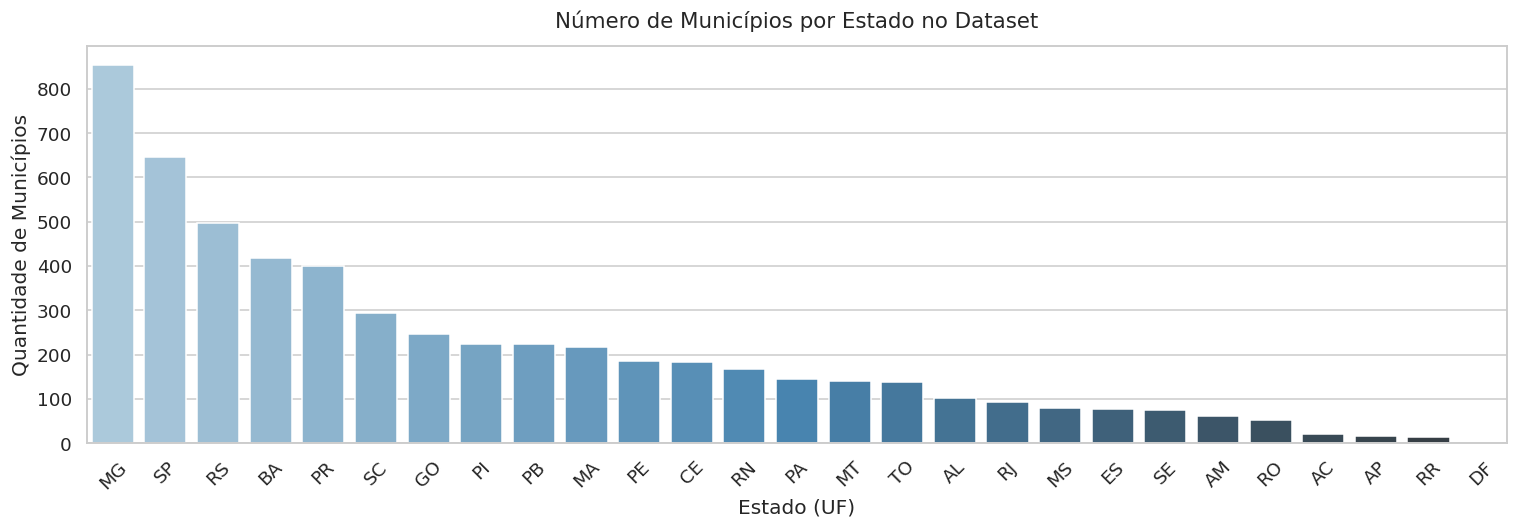

Fonte: elaborado pelos autores com base no dataset Brazilian Cities (2026).
Fonte: elaborado pelos autores (2026).


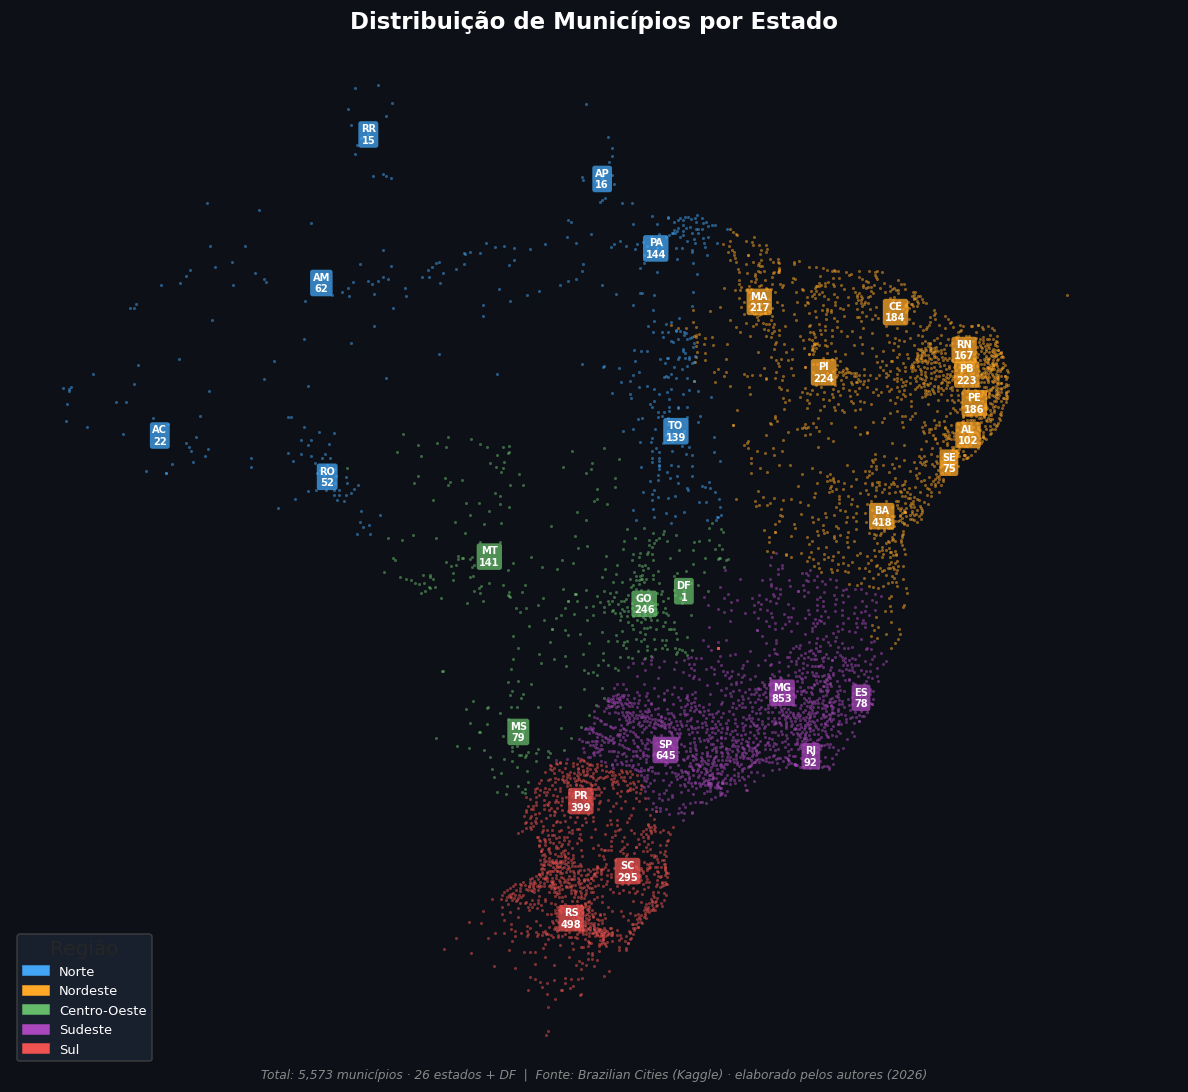

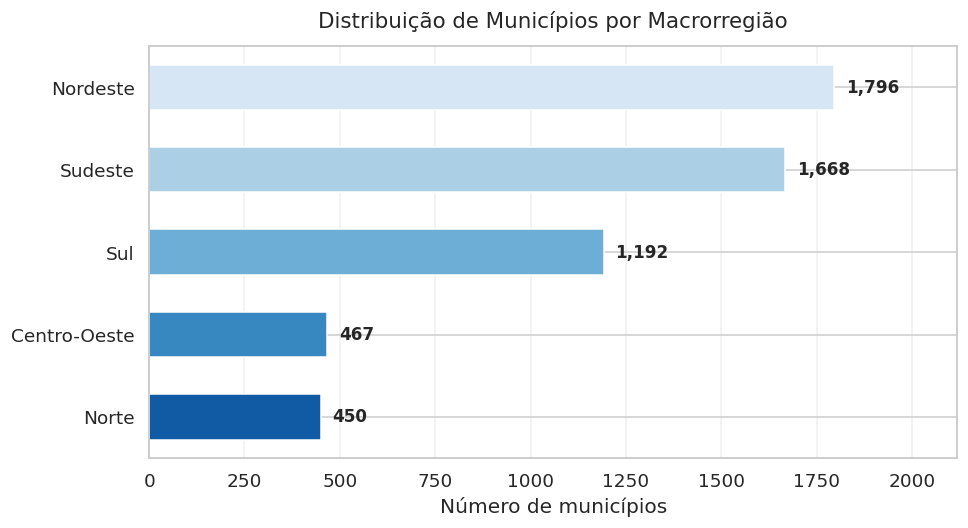

Fonte: elaborado pelos autores (2026).


In [ ]:
contagem_estados = df['state'].value_counts().reset_index()
contagem_estados.columns = ['Estado', 'Qtd. Cidades']

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=contagem_estados, x='Estado', y='Qtd. Cidades', palette='Blues_d', ax=ax)
ax.set_title('Número de Municípios por Estado no Dataset', fontsize=14, pad=12)
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Quantidade de Municípios')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_cidades_por_estado.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores com base no dataset Brazilian Cities (2026).')

CORES_REGIAO_MAP = {
    'Norte':        '#42A5F5',
    'Nordeste':     '#FFA726',
    'Centro-Oeste': '#66BB6A',
    'Sudeste':      '#AB47BC',
    'Sul':          '#EF5350',
}

contagem_map = df['state'].value_counts().reset_index()
contagem_map.columns = ['state', 'n_municipios']
df_mapa = df.dropna(subset=['lat', 'long']).merge(contagem_map, on='state')

fig, ax = plt.subplots(figsize=(11, 12), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

for regiao, grupo in df_mapa.groupby('regiao'):
    ax.scatter(grupo['long'], grupo['lat'],
               c=CORES_REGIAO_MAP.get(regiao, '#999'),
               s=4, alpha=0.5, linewidths=0, zorder=2, label=regiao)

centroides = df_mapa.groupby('state').agg(
    lat_c=('lat', 'median'), lon_c=('long', 'median'),
    n=('n_municipios', 'first'), regiao=('regiao', 'first')
).reset_index()

for _, row in centroides.iterrows():
    cor = CORES_REGIAO_MAP.get(row['regiao'], '#fff')
    ax.text(row['lon_c'], row['lat_c'],
            f"{row['state']}\n{row['n']:,}",
            ha='center', va='center', fontsize=6.5, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25', fc=cor, alpha=0.75, ec='none'), zorder=5)

import matplotlib.patches as mpatches
legenda = [mpatches.Patch(color=c, label=r) for r, c in CORES_REGIAO_MAP.items()]
ax.legend(handles=legenda, title='Região', fontsize=8.5, loc='lower left',
          facecolor='#1c2333', edgecolor='#444', labelcolor='white')

ax.set_xlim(-75, -28)
ax.set_ylim(-35, 6)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('Distribuição de Municípios por Estado',
             fontsize=15, fontweight='bold', color='white', pad=14)
ax.text(0.5, -0.01,
    f'Total: {len(df):,} municípios · 26 estados + DF  |  '
    'Fonte: Brazilian Cities (Kaggle) · elaborado pelos autores (2026)',
    transform=ax.transAxes, ha='center', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.savefig('g1_mapa_municipios.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Fonte: elaborado pelos autores (2026).')
plt.show()

mun_por_regiao = df.groupby('regiao').size().reset_index(name='n').sort_values('n', ascending=True)

# Generate a sequential blue pastel palette
pastel_blue_palette = sns.color_palette('Blues_r', n_colors=len(mun_por_regiao))
colors = pastel_blue_palette

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(mun_por_regiao['regiao'], mun_por_regiao['n'],
               color=colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, mun_por_regiao['n']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Distribuição de Municípios por Macrorregião', fontsize=14, pad=12)
ax.set_xlabel('Número de municípios')
ax.set_xlim(0, mun_por_regiao['n'].max() * 1.18)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_municipios_regiao.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:Nordeste e Sudeste concentram ~60% dos municípios → filtros regionais prioritários no app
# Insight: MG e SP concentram ~30% dos municípios → risco de viés nos modelos de recomendação

### 3.3 Distribuição do PIB per Capita
> Variável numérica contínua — histograma + KDE, escala normal e logarítmica.

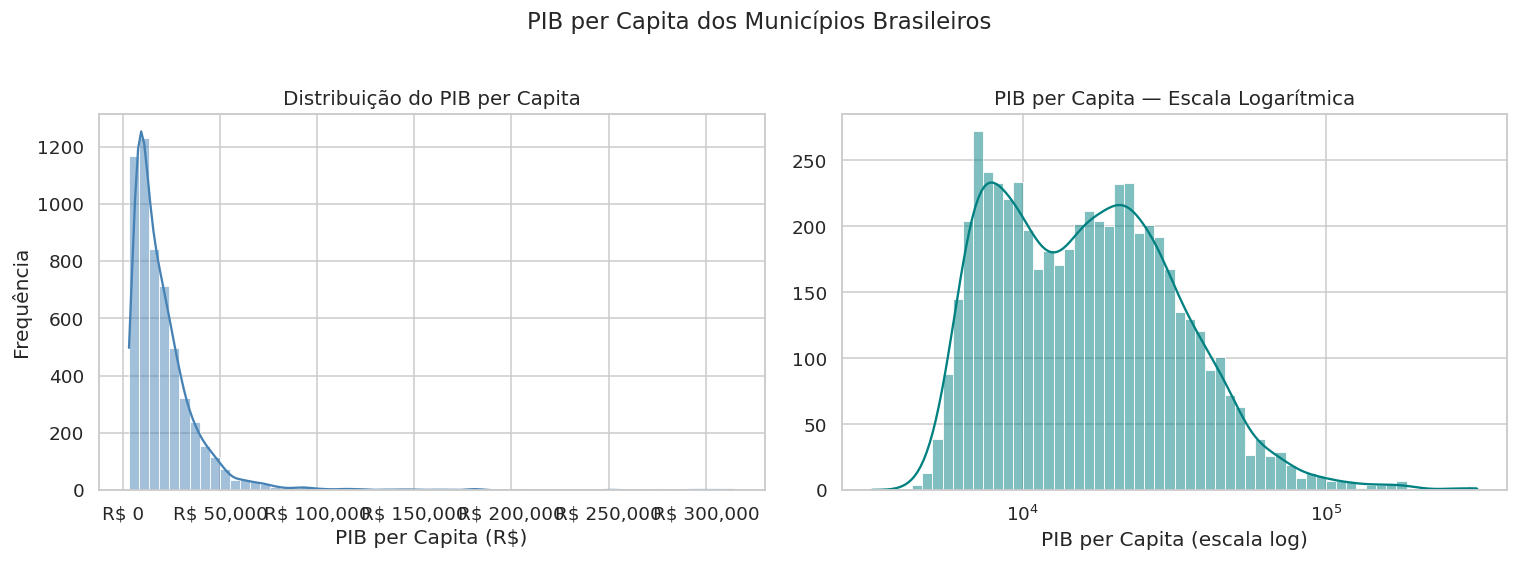

Fonte: elaborado pelos autores (2026).

--- Estatísticas: PIB per Capita ---
count      R$ 5,573.00
mean      R$ 21,123.35
std       R$ 20,327.54
min        R$ 3,190.57
25%        R$ 9,061.72
50%       R$ 15,869.62
75%       R$ 26,154.25
max      R$ 314,637.69
Name: gdp_capita, dtype: object


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['gdp_capita'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribuição do PIB per Capita', fontsize=13)
axes[0].set_xlabel('PIB per Capita (R$)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

sns.histplot(df['gdp_capita'], bins=60, kde=True, color='teal', log_scale=True, ax=axes[1])
axes[1].set_title('PIB per Capita — Escala Logarítmica', fontsize=13)
axes[1].set_xlabel('PIB per Capita (escala log)')
axes[1].set_ylabel('')

plt.suptitle('PIB per Capita dos Municípios Brasileiros', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig_pib_distribuicao.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

print('\n--- Estatísticas: PIB per Capita ---')
print(df['gdp_capita'].describe().apply(lambda x: f'R$ {x:,.2f}'))

# Insight para o sistema:Distribuição fortemente assimétrica → normalização (log) necessária antes da modelagem ML

### 3.4 Distribuição da População Total

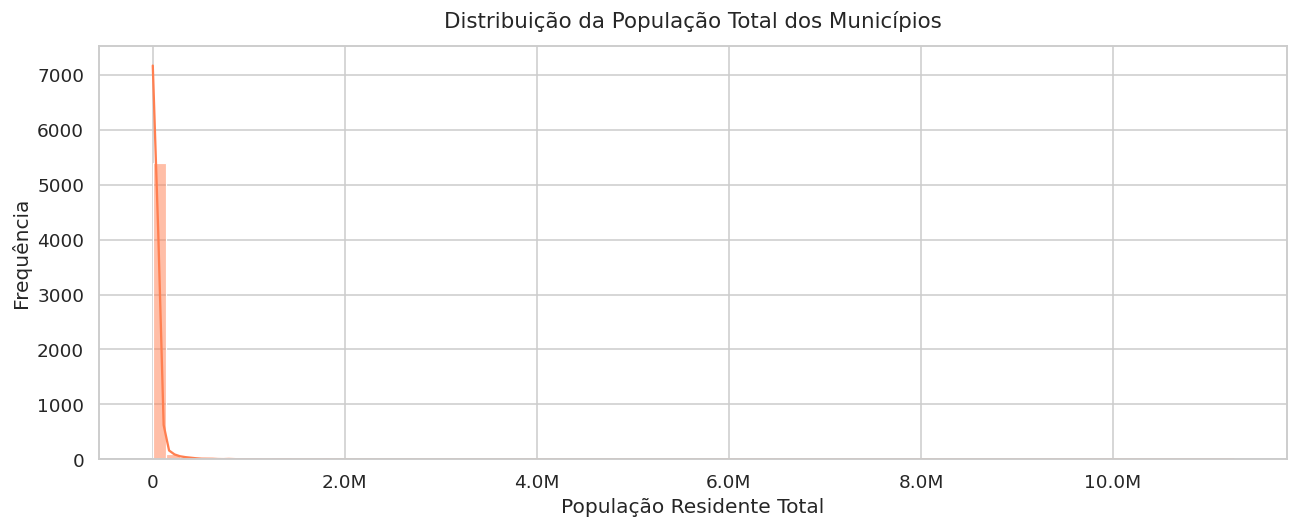

Fonte: elaborado pelos autores (2026).

--- Estatísticas: População ---
count         5,573
mean         34,244
std         202,969
min             805
25%           5,238
50%          10,934
75%          23,397
max      11,253,503
Name: ibge_res_pop, dtype: object


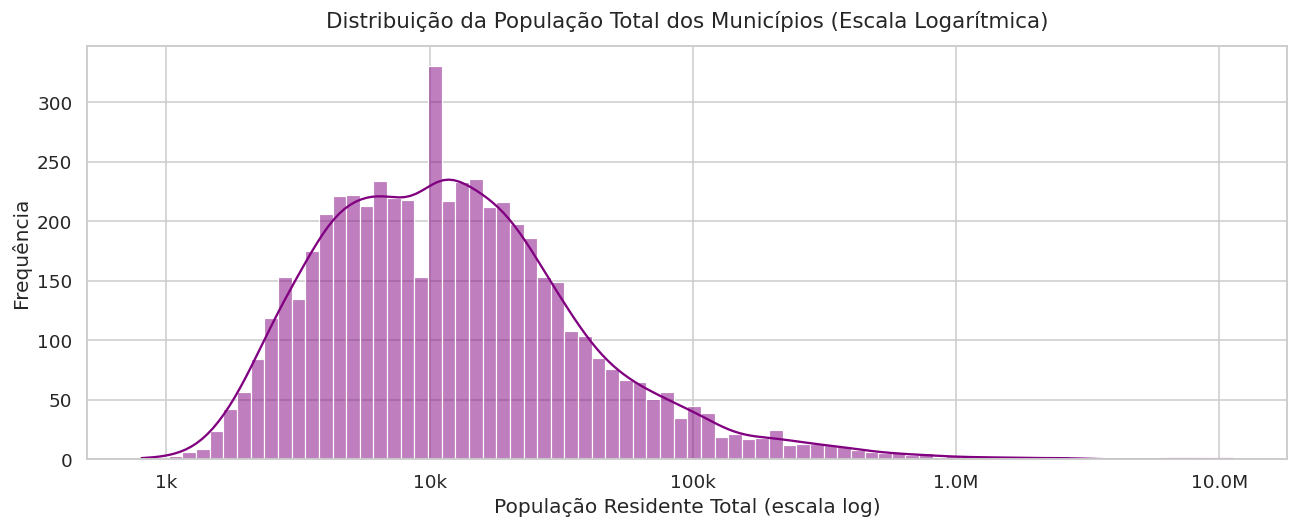

Fonte: elaborado pelos autores (2026).


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['ibge_res_pop'], bins=80, kde=True, color='coral', ax=ax)
ax.set_title('Distribuição da População Total dos Municípios', fontsize=14, pad=12)
ax.set_xlabel('População Residente Total')
ax.set_ylabel('Frequência')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')))
plt.tight_layout()
plt.savefig('fig_populacao.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

print('\n--- Estatísticas: População ---')
print(df['ibge_res_pop'].describe().apply(lambda x: f'{x:,.0f}'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['ibge_res_pop'], bins=80, kde=True, color='purple', log_scale=True, ax=ax)
ax.set_title('Distribuição da População Total dos Municípios (Escala Logarítmica)', fontsize=14, pad=12)
ax.set_xlabel('População Residente Total (escala log)')
ax.set_ylabel('Frequência')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')))
plt.tight_layout()
plt.savefig('fig_populacao_log.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')
# Insight: A distribuição populacional é naturalmente assimétrica, com muitos municípios pequenos e poucos grandes. Gráficos lineares podem "espremer" a maioria dos dados. Utilizar uma escala logarítmica permite uma visualização mais clara e detalhada dessa distribuição, especialmente para os menores municípios.

### 3.5 Infraestrutura de Hospedagem — Hotéis e Leitos


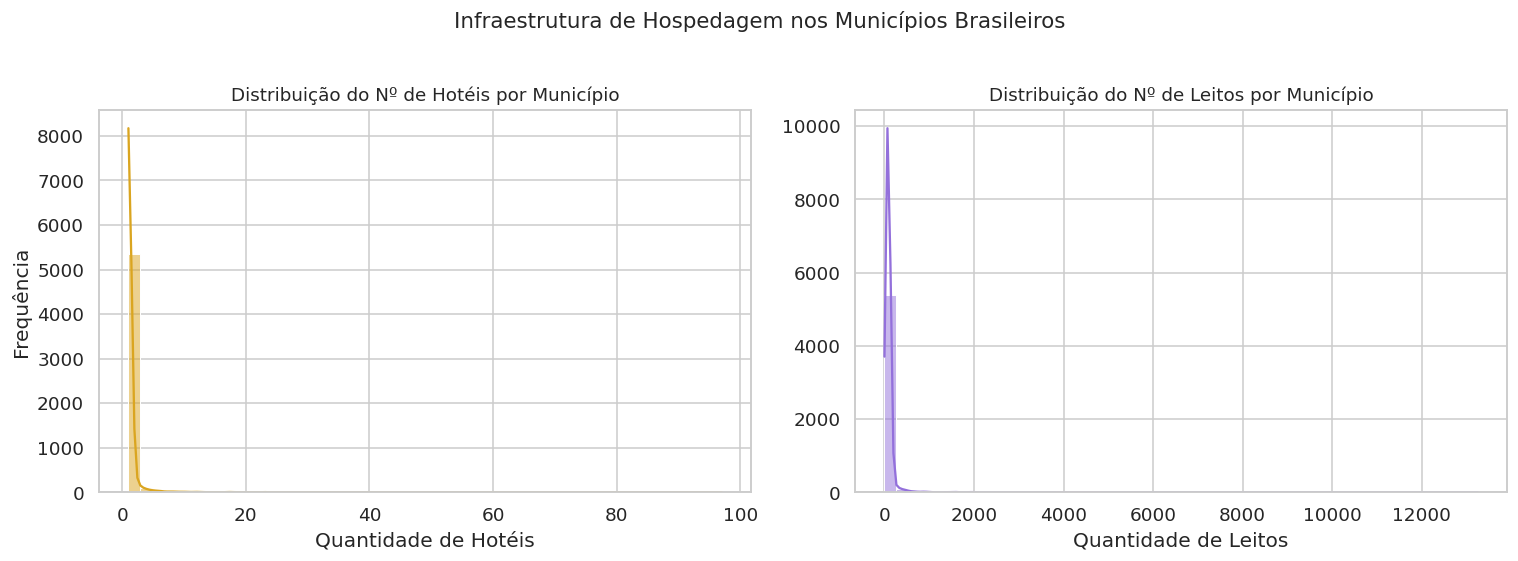

Fonte: elaborado pelos autores (2026).

🏨 Municípios sem nenhum hotel registrado: 0 (0.0%)


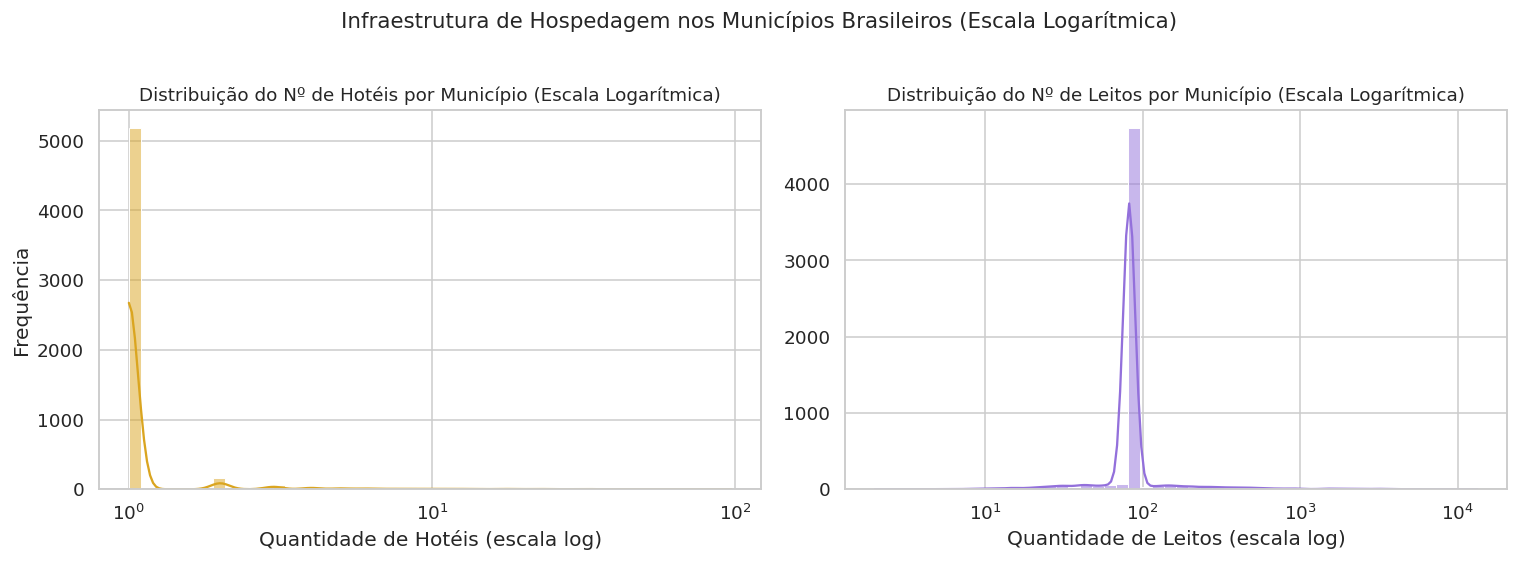

Fonte: elaborado pelos autores (2026).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['hotels'], bins=50, kde=True, color='goldenrod', ax=axes[0])
axes[0].set_title('Distribuição do Nº de Hotéis por Município', fontsize=12)
axes[0].set_xlabel('Quantidade de Hotéis')
axes[0].set_ylabel('Frequência')

sns.histplot(df['beds'], bins=50, kde=True, color='mediumpurple', ax=axes[1])
axes[1].set_title('Distribuição do Nº de Leitos por Município', fontsize=12)
axes[1].set_xlabel('Quantidade de Leitos')
axes[1].set_ylabel('')

plt.suptitle('Infraestrutura de Hospedagem nos Municípios Brasileiros', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_hospedagem.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

sem_hotel = (df['hotels'] == 0).sum()
print(f'\n🏨 Municípios sem nenhum hotel registrado: {sem_hotel:,} ({sem_hotel/len(df)*100:.1f}%)')

# Insight para o sistema: ~84% das cidades têm zero hotéis → leitos_1000hab é variável-chave para identificar joias escondidas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['hotels'], bins=50, kde=True, color='goldenrod', log_scale=True, ax=axes[0])
axes[0].set_title('Distribuição do Nº de Hotéis por Município (Escala Logarítmica)', fontsize=12)
axes[0].set_xlabel('Quantidade de Hotéis (escala log)')
axes[0].set_ylabel('Frequência')

sns.histplot(df['beds'], bins=50, kde=True, color='mediumpurple', log_scale=True, ax=axes[1])
axes[1].set_title('Distribuição do Nº de Leitos por Município (Escala Logarítmica)', fontsize=12)
axes[1].set_xlabel('Quantidade de Leitos (escala log)')
axes[1].set_ylabel('')

plt.suptitle('Infraestrutura de Hospedagem nos Municípios Brasileiros (Escala Logarítmica)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_hospedagem_log.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Observação sobre a imputação: O count de 'Municípios sem nenhum hotel registrado' na célula anterior é 0 devido à imputação de NaN com a mediana (1 para hotels, 82 para beds).
# Os dados originais continham muitos NaN para estas colunas (84%), o que provavelmente indicava ausência de infraestrutura em grande parte dos municípios.

### 3.6 Infraestrutura Hoteleira por Topografia


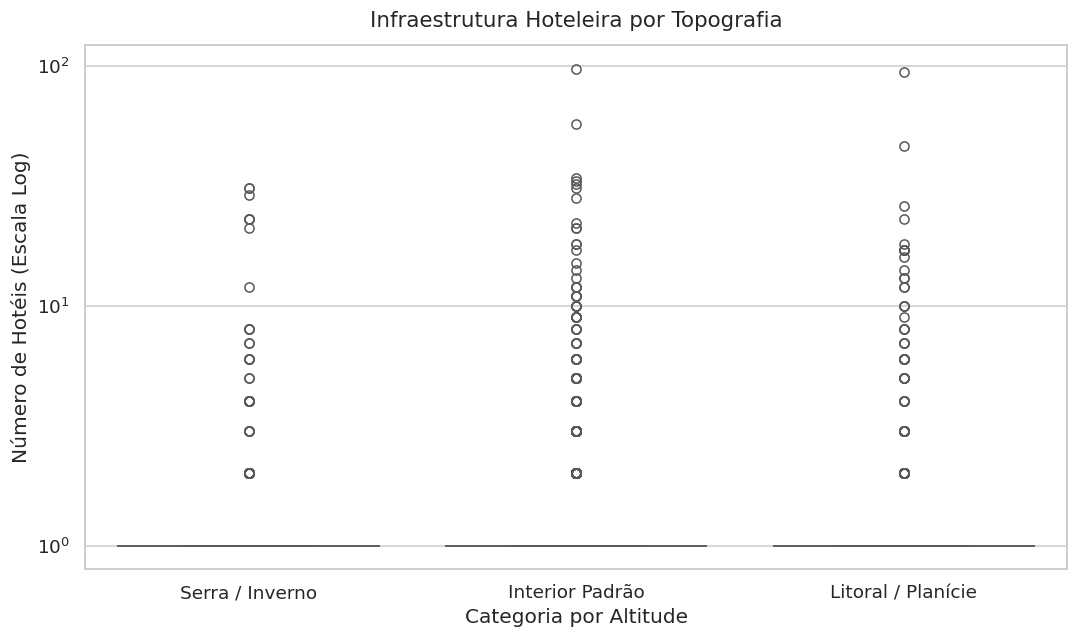

Fonte: elaborado pelos autores (2026).


In [ ]:
df_turismo = df[(df['hotels'] > 0) & (df['categoria_topografica'] != 'Desconhecido')]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_turismo, x='categoria_topografica', y='hotels', palette='Set2', ax=ax)
ax.set_yscale('log')
ax.set_title('Infraestrutura Hoteleira por Topografia', fontsize=14, pad=12)
ax.set_xlabel('Categoria por Altitude')
ax.set_ylabel('Número de Hotéis (Escala Log)')
plt.tight_layout()
plt.savefig('fig_hotel_topografia.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:
# Litoral domina volume; Serra tem menos hotéis mas maiores (outliers de alto padrão)


### 3.7 Disponibilidade de Uber por Estado


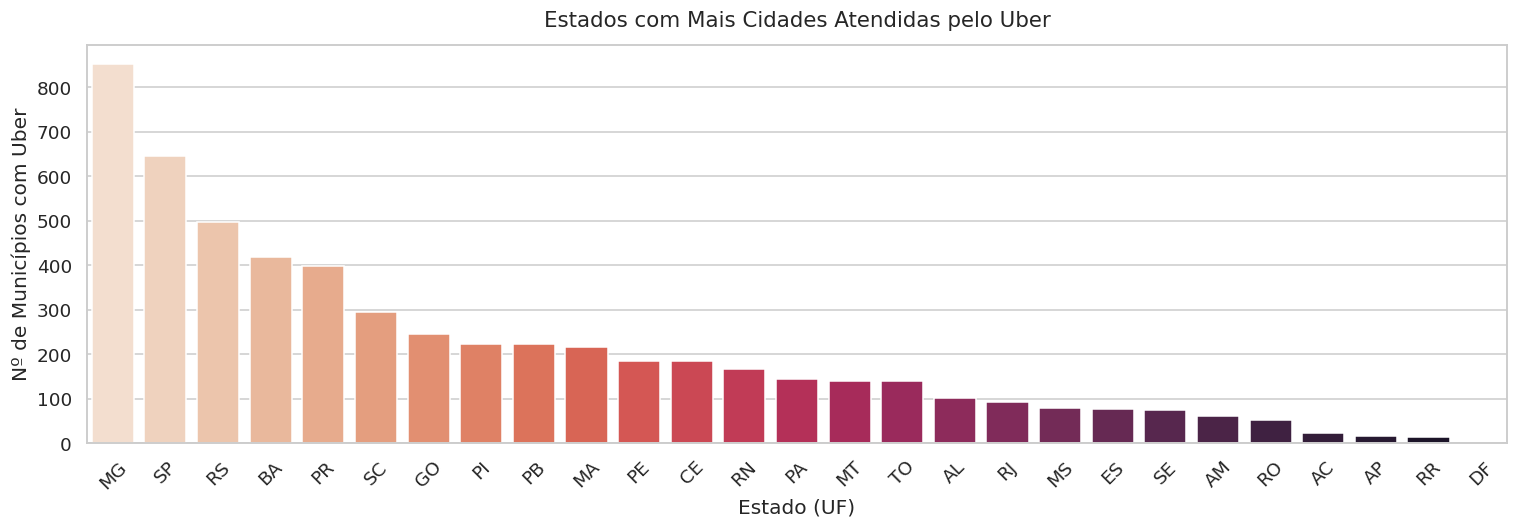

Fonte: elaborado pelos autores (2026).

🚗 Municípios com Uber: 5,573 de 5,573 (100.0%)


In [ ]:
uber_por_estado = (
    df[df['uber'] == 1]
    .groupby('state')['city']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
uber_por_estado.columns = ['Estado', 'Cidades com Uber']

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=uber_por_estado, x='Estado', y='Cidades com Uber', palette='rocket_r', ax=ax)
ax.set_title('Estados com Mais Cidades Atendidas pelo Uber', fontsize=14, pad=12)
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Nº de Municípios com Uber')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_uber.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

total_uber = df['uber'].sum()
print(f'\n🚗 Municípios com Uber: {int(total_uber):,} de {len(df):,} ({total_uber/len(df)*100:.1f}%)')

# Insight para o sistema: Menos de 5% das cidades têm Uber → variável binária relevante como proxy de conectividade

### 3.8 Top 20 Polos de Alojamento e Alimentação


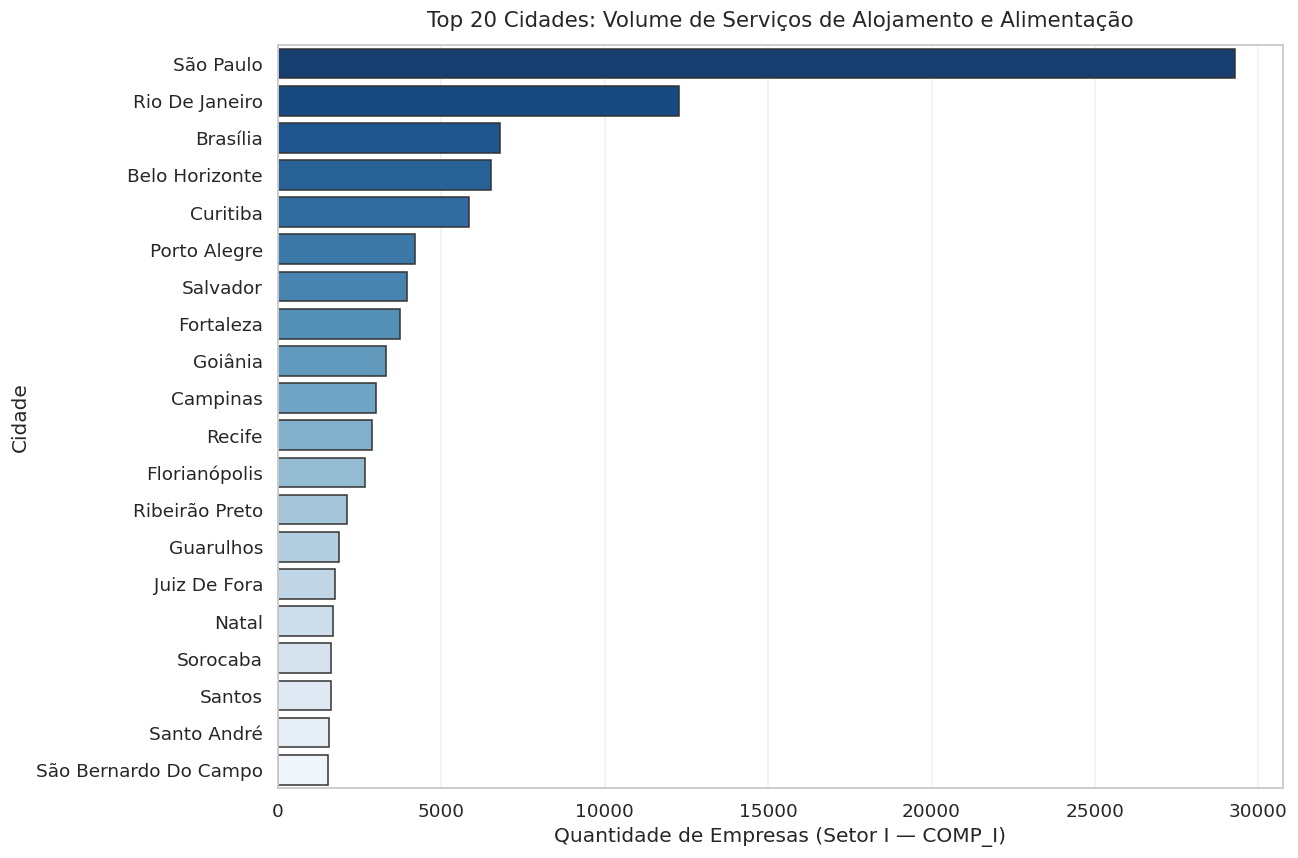

Fonte: elaborado pelos autores (2026).


In [ ]:
df_top = df.sort_values('comp_i', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df_top, x='comp_i', y='city', palette='Blues_r', edgecolor='0.2', ax=ax)
ax.set_title('Top 20 Cidades: Volume de Serviços de Alojamento e Alimentação', fontsize=14, pad=12)
ax.set_xlabel('Quantidade de Empresas (Setor I — COMP_I)')
ax.set_ylabel('Cidade')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_comp_i_top20.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:comp_i = índice de comércio de hospedagem e alimentação → proxy de infraestrutura turística

---
## 🔗 Fase 4 — Análise Bivariada e Multivariada

Investigamos **relações entre variáveis** para descobrir padrões e gerar hipóteses.

### 4.1 PIB Médio por Macrorregião


Fonte: elaborado pelos autores (2026).


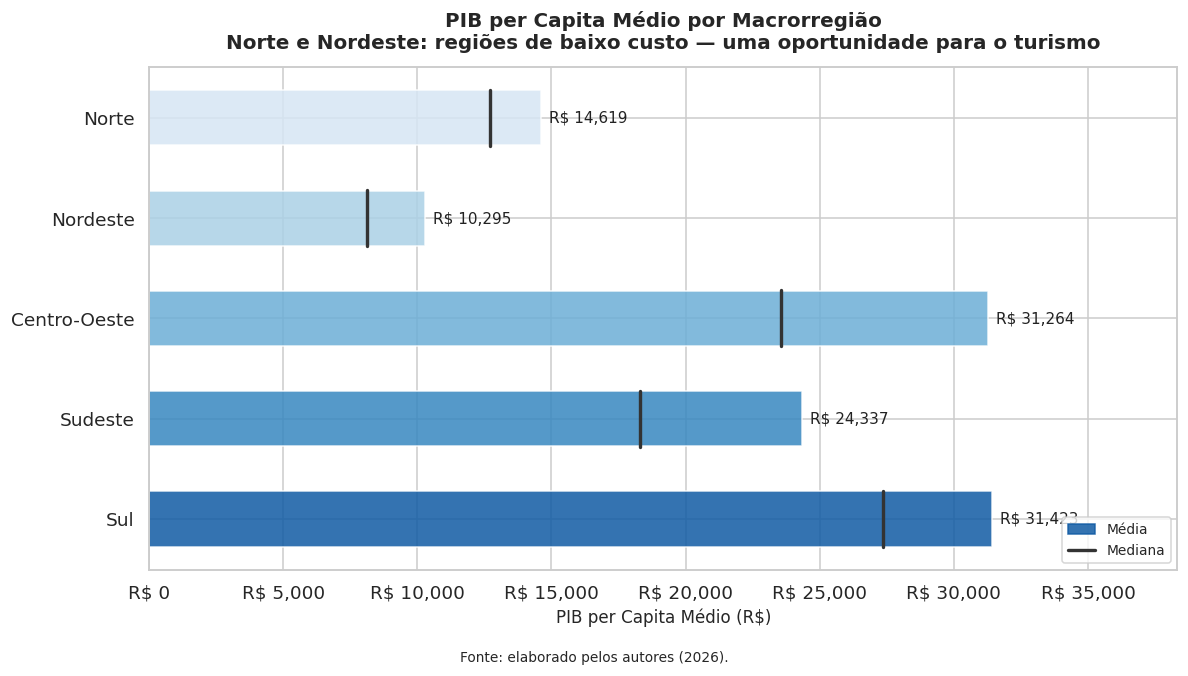

In [ ]:
CORES_REG = {
    'Norte':        '#42A5F5',
    'Nordeste':     '#FFA726',
    'Centro-Oeste': '#66BB6A',
    'Sudeste':      '#AB47BC',
    'Sul':          '#EF5350',
}
ORDEM_REG = ['Sul', 'Sudeste', 'Centro-Oeste', 'Nordeste', 'Norte']

resumo_pib = (
    df.groupby('regiao')['gdp_capita']
    .agg(media='mean', mediana='median')
    .reset_index()
)
resumo_pib = resumo_pib.set_index('regiao').loc[ORDEM_REG].reset_index()

# Generate a sequential blue pastel palette for all bars
pastel_blue_palette = sns.color_palette('Blues_r', n_colors=len(resumo_pib))
cores_bar = pastel_blue_palette

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(resumo_pib['regiao'], resumo_pib['media'],
               color=cores_bar, alpha=0.85, edgecolor='white', height=0.55)

for i, row in resumo_pib.iterrows():
    ax.plot([row['mediana'], row['mediana']], [i - 0.28, i + 0.28],
            color='#333', linewidth=2.2, zorder=5,
            label='Mediana' if i == 0 else '')

for bar, val in zip(bars, resumo_pib['media']):
    ax.text(val + 300, bar.get_y() + bar.get_height()/2,
            f'R$ {val:,.0f}', va='center', fontsize=10, color='#222')

ax.set_xlabel('PIB per Capita Médio (R$)', fontsize=11)
ax.set_title(
    'PIB per Capita Médio por Macrorregião\n'
    'Norte e Nordeste: regiões de baixo custo — uma oportunidade para o turismo',
    fontsize=13, fontweight='bold', pad=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlim(0, resumo_pib['media'].max() * 1.22)

handles = [
    plt.Rectangle((0,0),1,1, color=cores_bar[0], alpha=0.85, label='Média'), # Use first color from the new pastel blue palette
    plt.Line2D([0],[0], color='#333', linewidth=2.2, label='Mediana')
]
ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.figtext(0.5, -0.02, 'Fonte: elaborado pelos autores (2026).', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('g2_pib_medio_regiao.png', dpi=150, bbox_inches='tight')
print('Fonte: elaborado pelos autores (2026).')
plt.show()

### 4.2 Heatmap de Correlação
> Visão geral de como variáveis econômicas e turísticas se relacionam.

Fonte: elaborado pelos autores (2026).


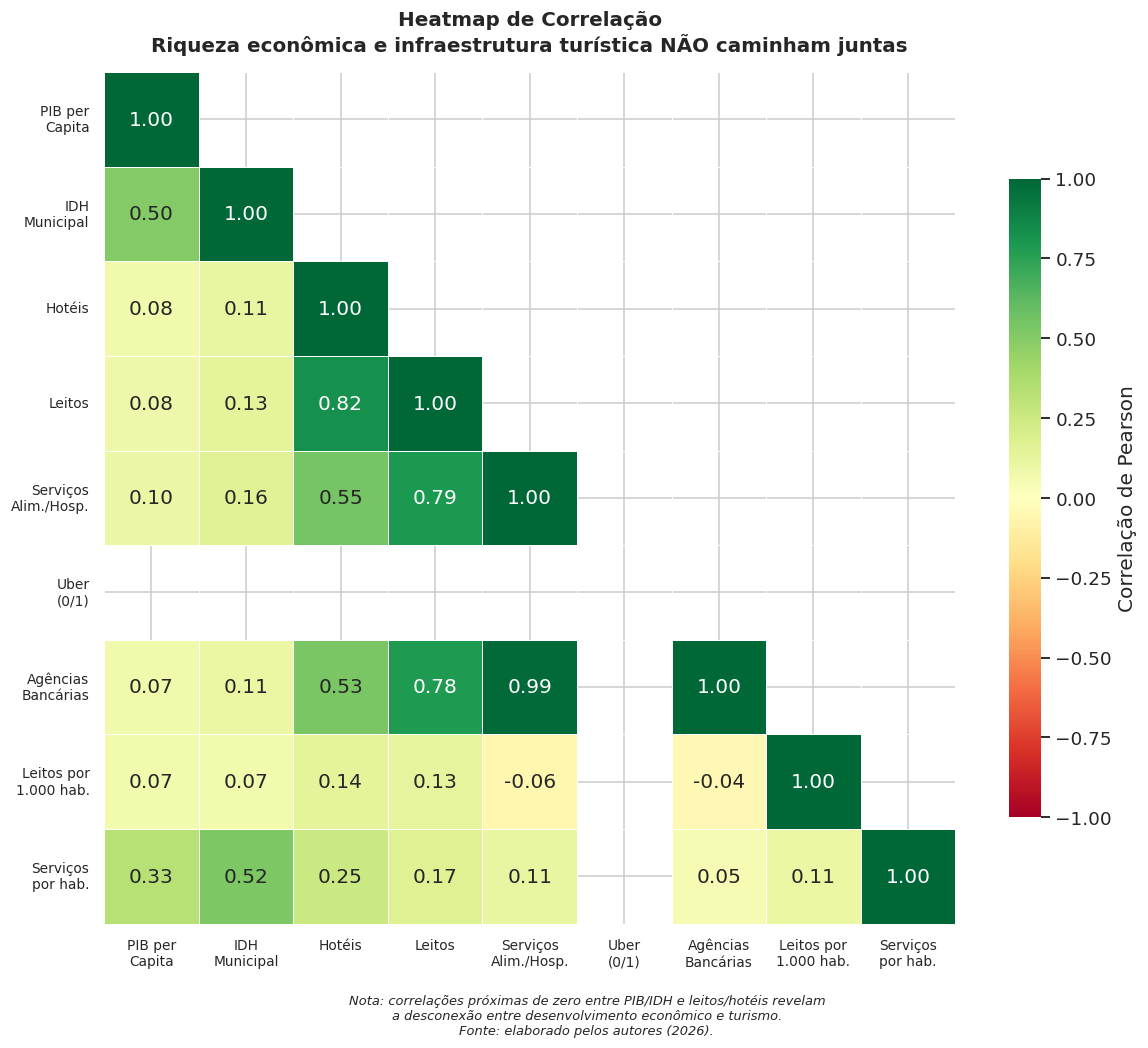

In [ ]:
VARS_CORR = {
    'gdp_capita':       'PIB per\nCapita',
    'idhm':             'IDH\nMunicipal',
    'hotels':           'Hotéis',
    'beds':             'Leitos',
    'comp_i':           'Serviços\nAlim./Hosp.',
    'uber':             'Uber\n(0/1)',
    'agencias_total':   'Agências\nBancárias',
    'leitos_1000hab':   'Leitos por\n1.000 hab.',
    'servicos_1000hab': 'Serviços\npor hab.',
}

sub_corr = df[list(VARS_CORR.keys())].copy()
sub_corr.columns = list(VARS_CORR.values())
corr_matrix = sub_corr.corr()

mask_arr = np.zeros(corr_matrix.shape, dtype=bool)
mask_arr[np.triu_indices_from(mask_arr, k=1)] = True

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask_arr, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Correlação de Pearson'},
    ax=ax
)
ax.set_title(
    'Heatmap de Correlação\n'
    'Riqueza econômica e infraestrutura turística NÃO caminham juntas',
    fontsize=13, fontweight='bold', pad=14
)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.figtext(
    0.5, -0.05, # Ajuste aqui para mover o texto para baixo
    'Nota: correlações próximas de zero entre PIB/IDH e leitos/hotéis revelam\n'
    'a desconexão entre desenvolvimento econômico e turismo.\n'
    'Fonte: elaborado pelos autores (2026).',
    ha='center', fontsize=8.5, style='italic'
)
plt.tight_layout()
plt.savefig('g3_heatmap_correlacao.png', dpi=150, bbox_inches='tight')
print('Fonte: elaborado pelos autores (2026).')
plt.show()

### 4.3 PIB per Capita × Serviços de Alojamento
> Cidades mais ricas têm mais infraestrutura turística?

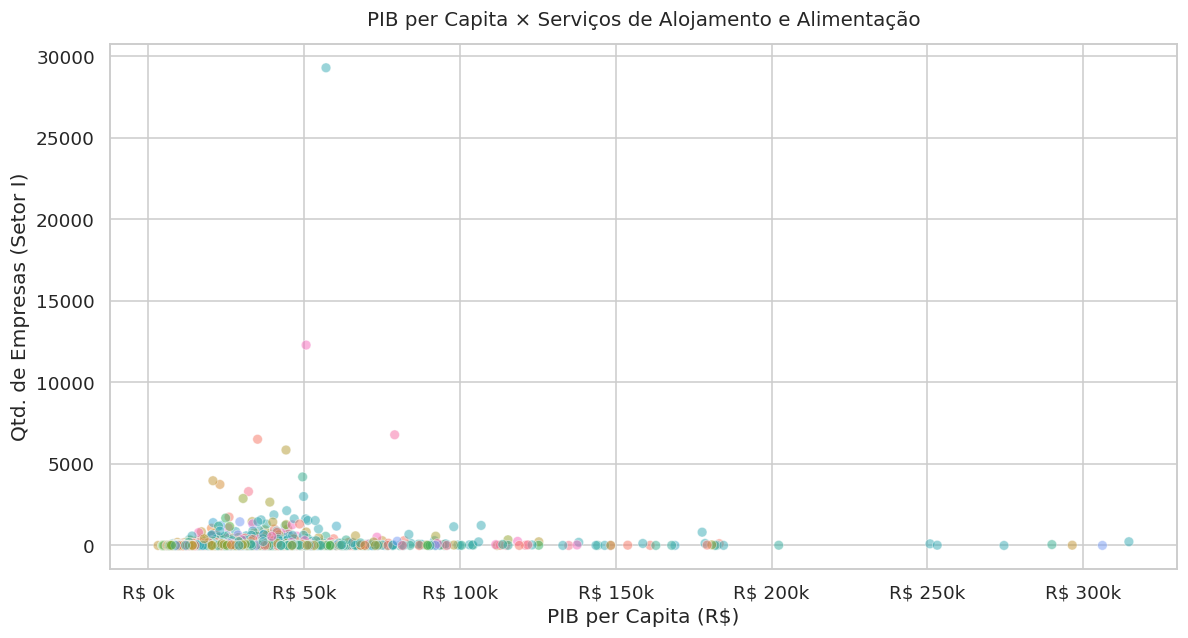

Fonte: elaborado pelos autores (2026).


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df, x='gdp_capita', y='comp_i',
                hue='state', alpha=0.5, s=40, legend=False, ax=ax)
ax.set_title('PIB per Capita × Serviços de Alojamento e Alimentação', fontsize=13, pad=12)
ax.set_xlabel('PIB per Capita (R$)')
ax.set_ylabel('Qtd. de Empresas (Setor I)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_scatter_pib_servicos.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight: A relação entre PIB per capita e infraestrutura turística é fraca (correlações muito baixas e ausência de tendência clara no scatter plot), indicando que cidades mais ricas não necessariamente possuem maior oferta de hotéis, leitos ou serviços — o que sugere oportunidades de identificar “joias escondidas” com potencial turístico ainda pouco explorado.

### 4.4 PIB per Capita × Tamanho Populacional


Fonte: elaborado pelos autores (2026).


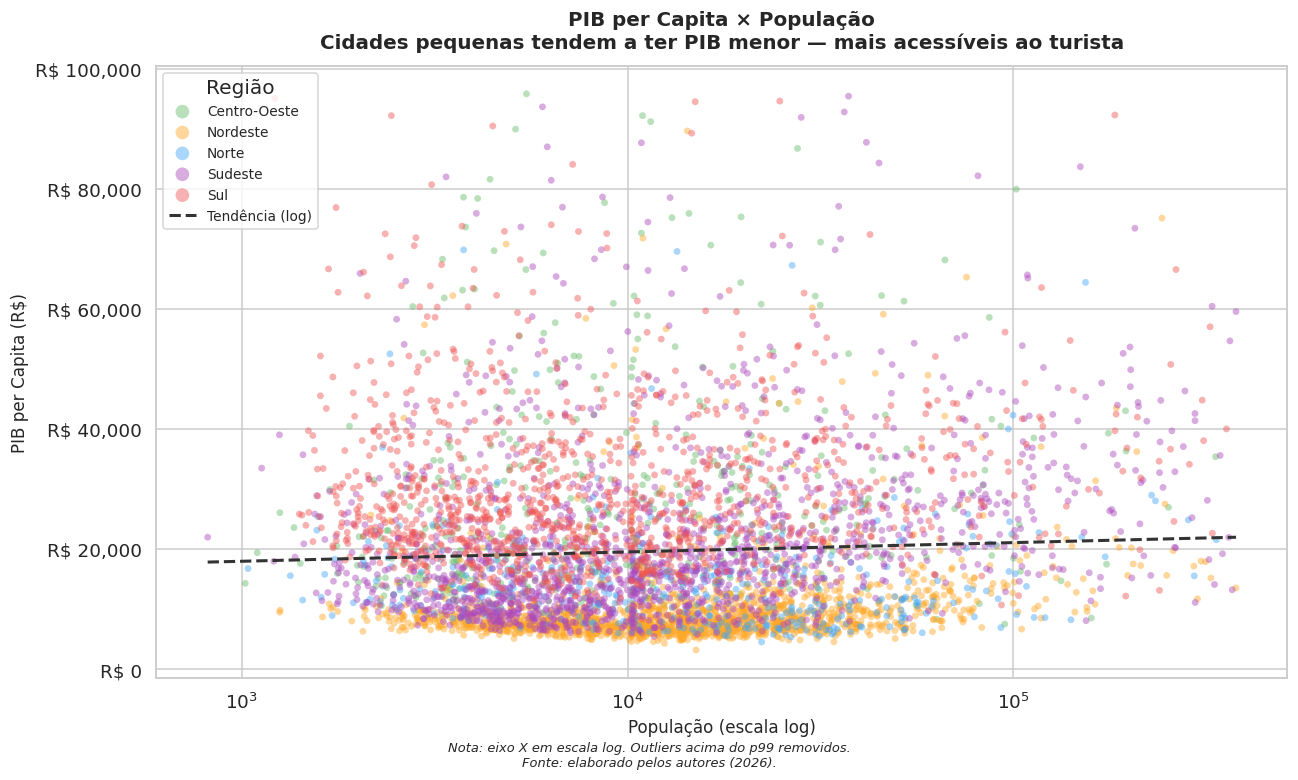

In [ ]:
CORES_REG4 = {
    'Norte':        '#42A5F5',
    'Nordeste':     '#FFA726',
    'Centro-Oeste': '#66BB6A',
    'Sudeste':      '#AB47BC',
    'Sul':          '#EF5350',
}

MAX_POP = df['ibge_res_pop'].quantile(0.99)
MAX_PIB = df['gdp_capita'].quantile(0.99)
sub_sc = df[(df['ibge_res_pop'] <= MAX_POP) & (df['gdp_capita'] <= MAX_PIB)].copy()

fig, ax = plt.subplots(figsize=(12, 7))

for regiao, grupo in sub_sc.groupby('regiao'):
    ax.scatter(grupo['ibge_res_pop'], grupo['gdp_capita'],
               label=regiao, color=CORES_REG4.get(regiao, '#999'),
               alpha=0.45, s=20, edgecolors='none')

z = np.polyfit(np.log10(sub_sc['ibge_res_pop'] + 1), sub_sc['gdp_capita'], 1)
xs = np.linspace(sub_sc['ibge_res_pop'].min(), sub_sc['ibge_res_pop'].max(), 300)
ax.plot(xs, np.poly1d(z)(np.log10(xs + 1)),
        color='#333', linewidth=2, linestyle='--', label='Tendência (log)')

top_pib = df.nlargest(5, 'gdp_capita')
for _, row in top_pib.iterrows():
    if row['ibge_res_pop'] <= MAX_POP and row['gdp_capita'] <= MAX_PIB:
        ax.annotate(row['city'], (row['ibge_res_pop'], row['gdp_capita']),
                    xytext=(8, 4), textcoords='offset points',
                    fontsize=7.5, color='#c00')

ax.set_xscale('log')
ax.set_xlabel('População (escala log)', fontsize=11)
ax.set_ylabel('PIB per Capita (R$)', fontsize=11)
ax.set_title(
    'PIB per Capita × População\n'
    'Cidades pequenas tendem a ter PIB menor — mais acessíveis ao turista',
    fontsize=13, fontweight='bold', pad=12
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='Região', fontsize=9, markerscale=2)
plt.figtext(0.5, -0.01,
    'Nota: eixo X em escala log. Outliers acima do p99 removidos.\n'
    'Fonte: elaborado pelos autores (2026).',
    ha='center', fontsize=8.5, style='italic')
plt.tight_layout()
plt.savefig('g4_scatter_pib_populacao.png', dpi=150, bbox_inches='tight')
print('Fonte: elaborado pelos autores (2026).')
plt.show()


### 4.5 Perfil Demográfico — Cidades Jovens vs. Cidades Idosas


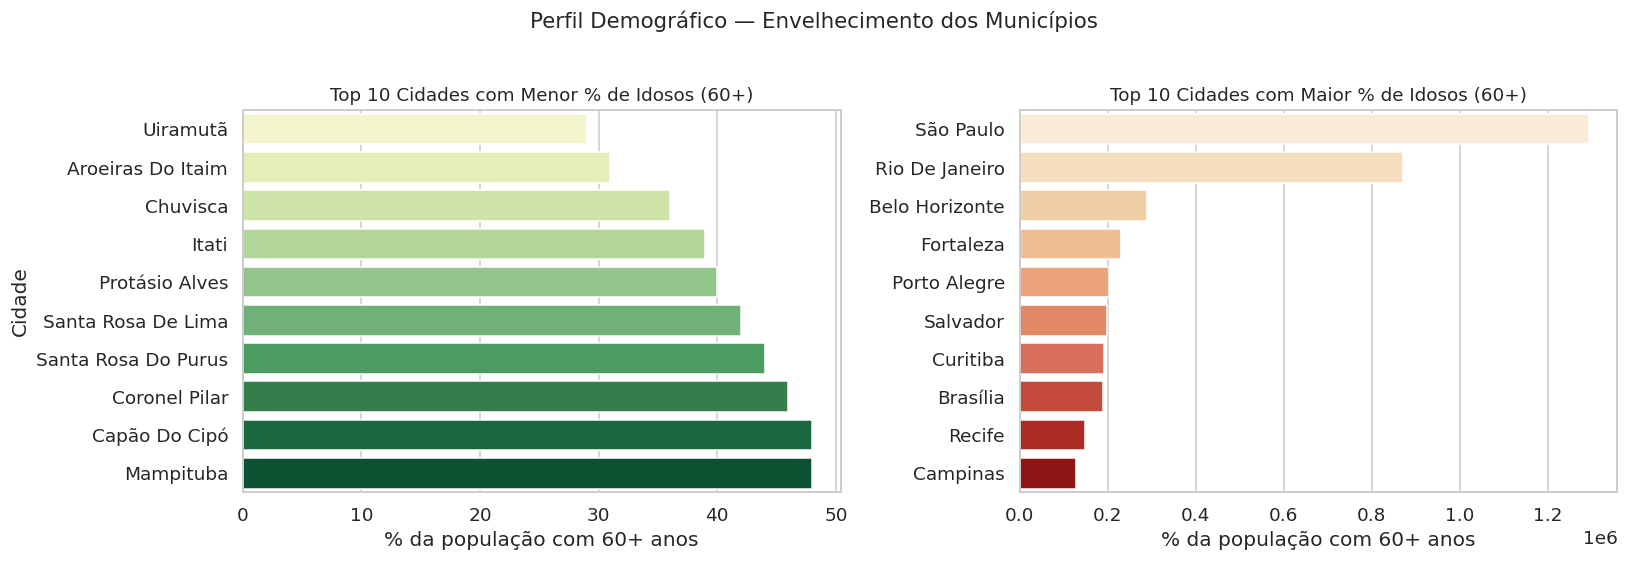

Fonte: elaborado pelos autores (2026).
Coluna utilizada: ibge_60


In [ ]:
# Identificar a coluna de idosos disponível no dataset
col_60 = [c for c in df.columns if '60' in c and c.startswith('ibge')]
if col_60:
    df['pct_idosos'] = df[col_60[0]]
    mais_jovens = df.nsmallest(10, 'pct_idosos')[['city','state','pct_idosos']]
    mais_idosas = df.nlargest(10, 'pct_idosos')[['city','state','pct_idosos']]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=mais_jovens, x='pct_idosos', y='city', palette='YlGn', ax=axes[0])
    axes[0].set_title('Top 10 Cidades com Menor % de Idosos (60+)', fontsize=12)
    axes[0].set_xlabel('% da população com 60+ anos')
    axes[0].set_ylabel('Cidade')

    sns.barplot(data=mais_idosas, x='pct_idosos', y='city', palette='OrRd', ax=axes[1])
    axes[1].set_title('Top 10 Cidades com Maior % de Idosos (60+)', fontsize=12)
    axes[1].set_xlabel('% da população com 60+ anos')
    axes[1].set_ylabel('')

    plt.suptitle('Perfil Demográfico — Envelhecimento dos Municípios', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_demografico.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Fonte: elaborado pelos autores (2026).')
    print(f'Coluna utilizada: {col_60[0]}')
else:
    print(f'⚠️ Colunas de faixa etária 60+ não encontradas. Colunas disponíveis: {[c for c in df.columns if "ibge" in c]}')

# Insight para o sistema: Norte = perfil jovem → turismo aventura/ecoturismo | Sul = envelhecido → turismo de lazer/saúde

### 4.6 Infraestrutura Bancária vs. Cidades com Uber por Estado


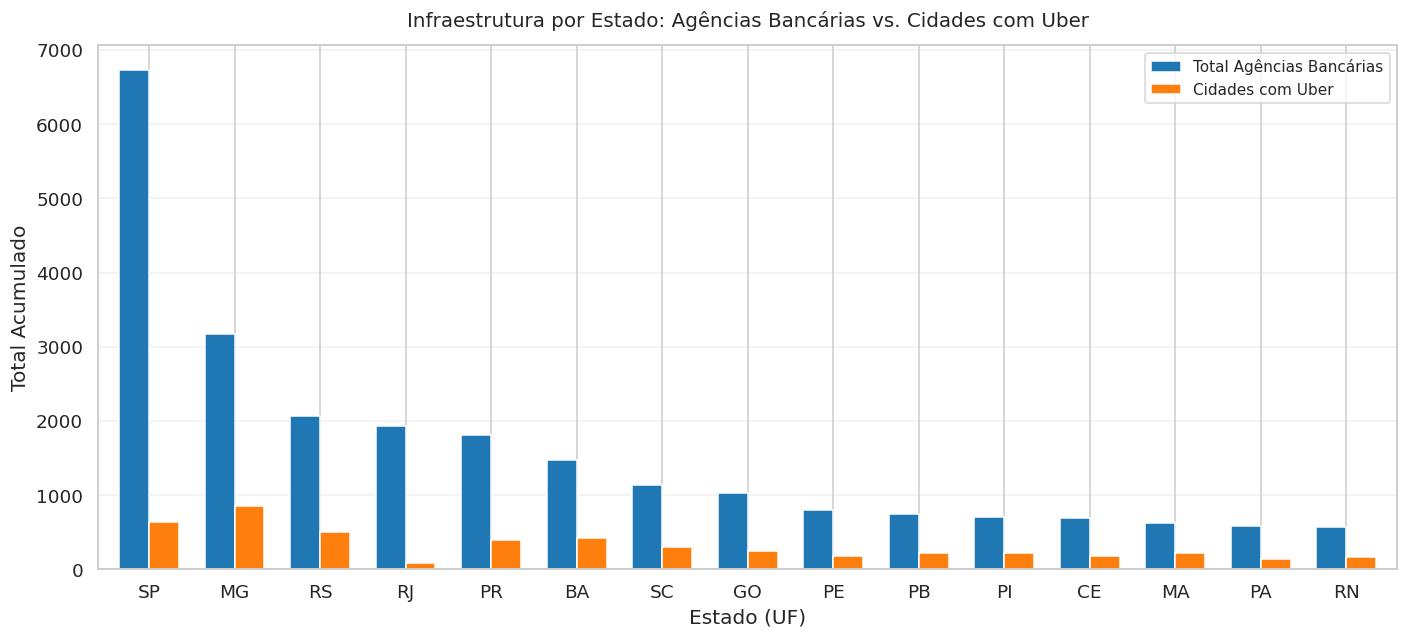

Fonte: elaborado pelos autores (2026).


In [ ]:
state_data = (df.groupby('state')
               .agg({'agencias_total': 'sum', 'uber': 'sum'})
               .sort_values('agencias_total', ascending=False)
               .head(15))
state_data.columns = ['Total Agências Bancárias', 'Cidades com Uber']

fig, ax = plt.subplots(figsize=(13, 6))
state_data.plot(kind='bar', ax=ax, color=['#1f77b4','#ff7f0e'], width=0.7)
ax.set_title('Infraestrutura por Estado: Agências Bancárias vs. Cidades com Uber', fontsize=13, pad=12)
ax.set_ylabel('Total Acumulado')
ax.set_xlabel('Estado (UF)')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Total Agências Bancárias', 'Cidades com Uber'], fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_bancos_uber.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:
# SP e RJ concentram bancos e Uber → alta acessibilidade; Norte tem pouca infraestrutura financeira

### 4.7 Ranking de Custo Estimado — Top 15 Cidades


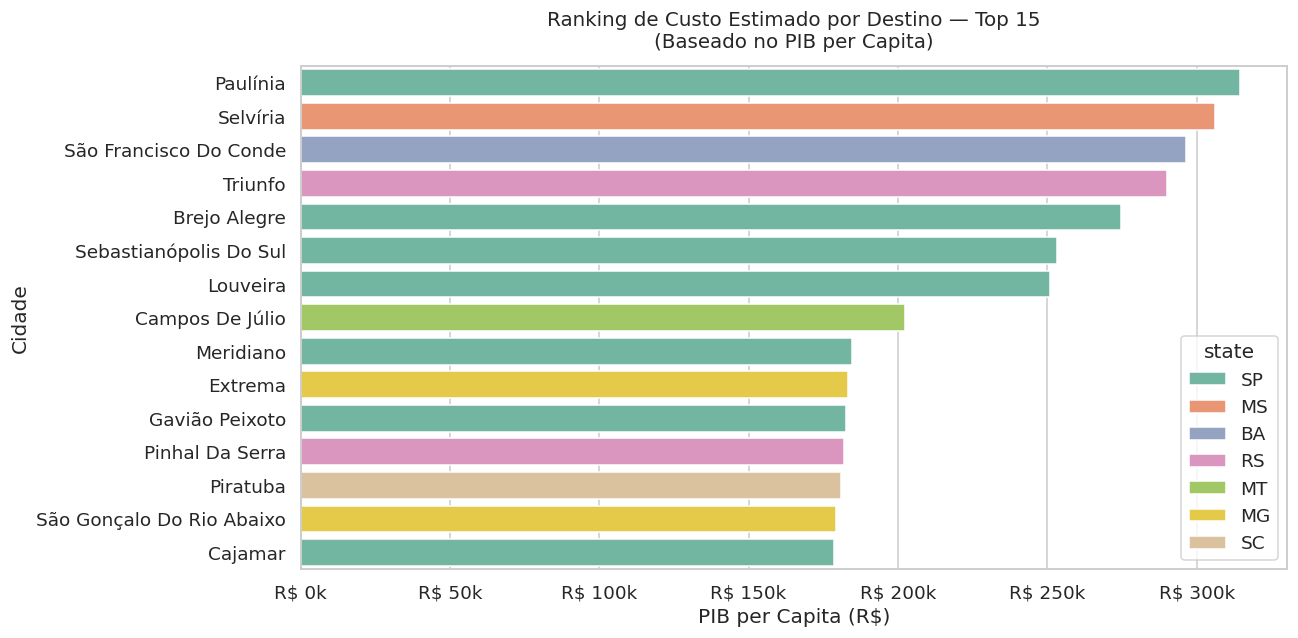

Fonte: elaborado pelos autores (2026).


In [ ]:
top15_pib = df.nlargest(15, 'gdp_capita')[['city','state','gdp_capita']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top15_pib, x='gdp_capita', y='city',
            hue='state', dodge=False, palette='Set2', ax=ax)
ax.set_title('Ranking de Custo Estimado por Destino — Top 15\n(Baseado no PIB per Capita)',
             fontsize=13, pad=12)
ax.set_xlabel('PIB per Capita (R$)')
ax.set_ylabel('Cidade')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_ranking_custo.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:
# Paulínia (SP), São Francisco do Conde (BA) = polos petroquímicos, NÃO destinos turísticos
# → justifica uso de IDH + leitos junto ao PIB na variável-target do modelo

### 4.8 Mapeamento de Destinos de Alto Custo-Benefício
> Scatter PIB × IDH com identificação dos "Achados Econômicos".

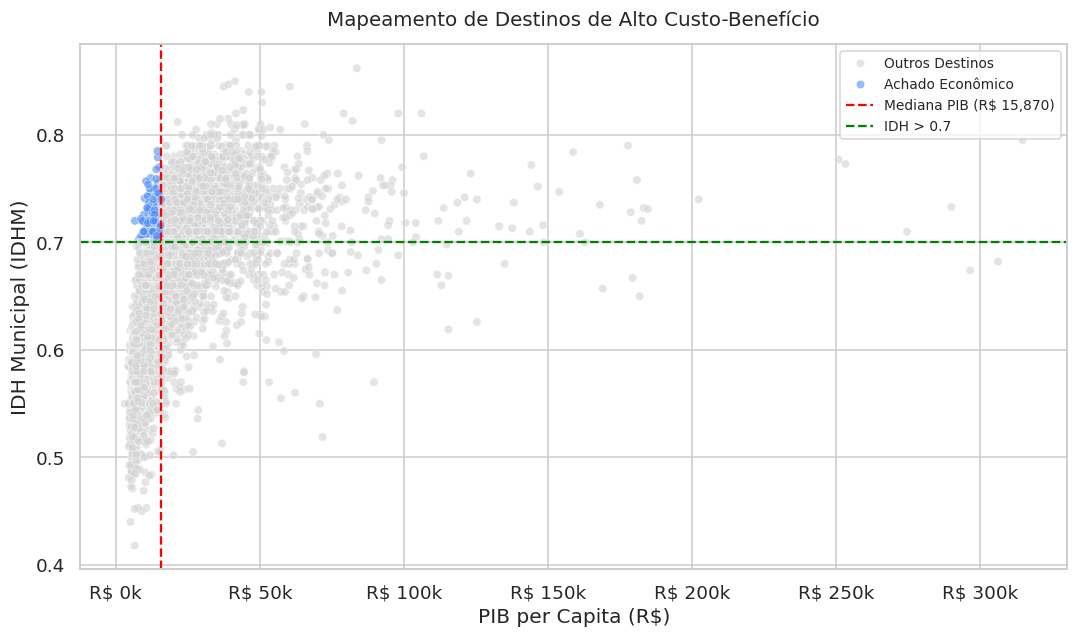

Fonte: elaborado pelos autores (2026).

💡 Destinos de alto custo-benefício identificados: 163 municípios


In [ ]:
mediana_pib = df['gdp_capita'].median()

df['perfil_destino'] = np.where(
    (df['gdp_capita'] < mediana_pib) & (df['idhm'] > 0.7),
    'Achado Econômico', 'Outros Destinos'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='gdp_capita', y='idhm', hue='perfil_destino',
                palette={'Achado Econômico':'#4F8EF7','Outros Destinos':'lightgray'},
                alpha=0.6, s=30, ax=ax)
ax.axvline(mediana_pib, color='red', linestyle='--', linewidth=1.5,
           label=f'Mediana PIB (R$ {mediana_pib:,.0f})')
ax.axhline(0.7, color='green', linestyle='--', linewidth=1.5, label='IDH > 0.7')
ax.set_title('Mapeamento de Destinos de Alto Custo-Benefício', fontsize=13, pad=12)
ax.set_xlabel('PIB per Capita (R$)')
ax.set_ylabel('IDH Municipal (IDHM)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}k'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_custo_beneficio.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

n_achados = (df['perfil_destino'] == 'Achado Econômico').sum()
print(f'\n💡 Destinos de alto custo-benefício identificados: {n_achados:,} municípios')

# Insight para o sistema: Estes são os candidatos ao filtro "custo-benefício" do app Brasil em Foco

### 4.9 IDH × Leitos por Habitante — Mapa dos Quadrantes (Joias Escondidas)
> O gráfico central do projeto. Quadrante Alto IDH + Baixa Hospedagem = candidatos à recomendação.

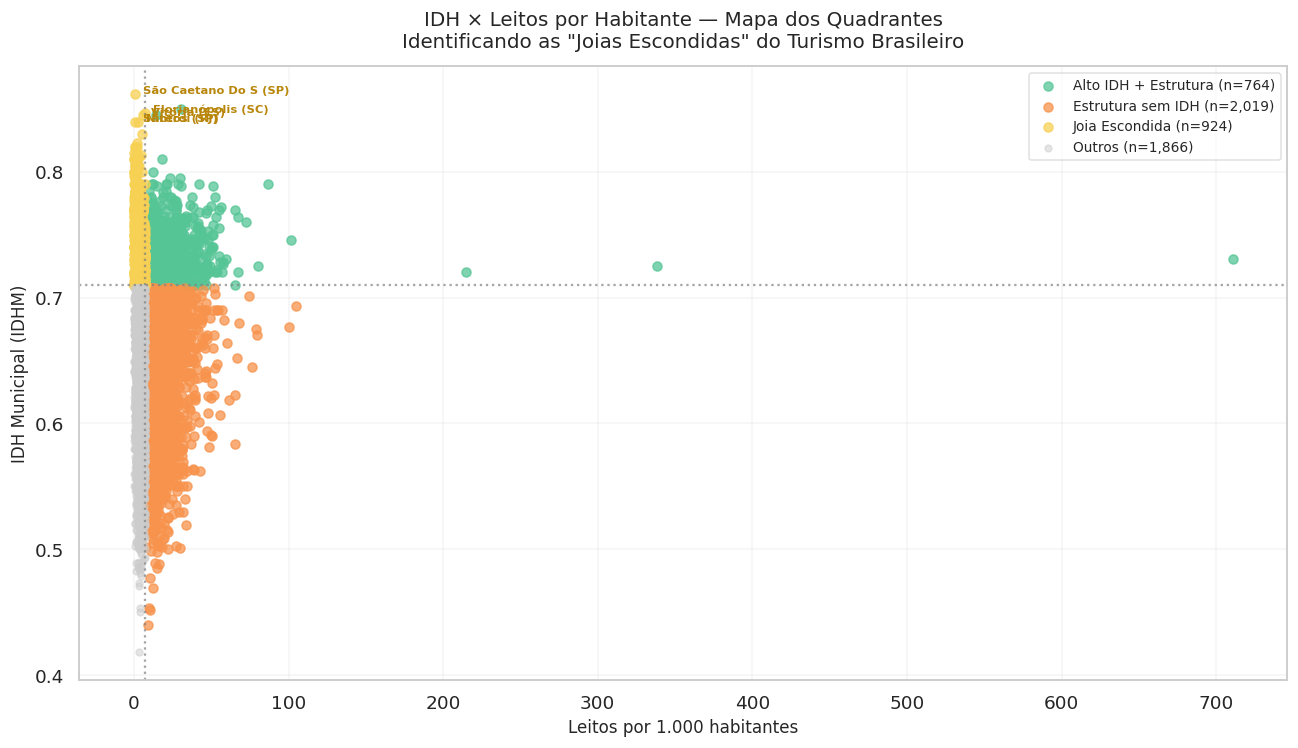

Fonte: elaborado pelos autores (2026).

💎 Joias Escondidas identificadas: 924 municípios
   IDH ≥ 0.710 (p70)  ·  leitos/1000hab ≤ 7.50 (mediana)


In [ ]:
mediana_leitos = df['leitos_1000hab'].median()
idhm_p70       = df['idhm'].quantile(0.70)

df['quadrante'] = 'Outros'
df.loc[(df['idhm'] >= idhm_p70) & (df['leitos_1000hab'] <= mediana_leitos), 'quadrante'] = 'Joia Escondida'
df.loc[(df['idhm'] >= idhm_p70) & (df['leitos_1000hab'] >  mediana_leitos), 'quadrante'] = 'Alto IDH + Estrutura'
df.loc[(df['idhm'] <  idhm_p70) & (df['leitos_1000hab'] >  mediana_leitos), 'quadrante'] = 'Estrutura sem IDH'

palette_q = {
    'Joia Escondida':     '#F7D154',
    'Alto IDH + Estrutura':'#56C596',
    'Estrutura sem IDH':  '#F7934C',
    'Outros':             '#CCCCCC'
}

fig, ax = plt.subplots(figsize=(12, 7))
for quad, grp in df.groupby('quadrante'):
    ax.scatter(grp['leitos_1000hab'], grp['idhm'],
               label=f'{quad} (n={len(grp):,})',
               color=palette_q[quad],
               alpha=0.5 if quad == 'Outros' else 0.75,
               s=20 if quad == 'Outros' else 35)

joias_anotadas = df[df['quadrante'] == 'Joia Escondida'].nlargest(5, 'idhm')
for _, row in joias_anotadas.iterrows():
    ax.annotate(f"  {row['city'][:16]} ({row['state']})",
                xy=(row['leitos_1000hab'], row['idhm']),
                fontsize=7.5, color='#B8860B', fontweight='bold')

ax.axvline(mediana_leitos, color='gray', linestyle=':', alpha=0.7)
ax.axhline(idhm_p70, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Leitos por 1.000 habitantes', fontsize=11)
ax.set_ylabel('IDH Municipal (IDHM)', fontsize=11)
ax.set_title('IDH × Leitos por Habitante — Mapa dos Quadrantes\nIdentificando as "Joias Escondidas" do Turismo Brasileiro',
             fontsize=13, pad=12)
ax.legend(fontsize=9, framealpha=0.6, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_joias_quadrantes.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

n_joias = (df['quadrante'] == 'Joia Escondida').sum()
print(f'\n💎 Joias Escondidas identificadas: {n_joias:,} municípios')
print(f'   IDH ≥ {idhm_p70:.3f} (p70)  ·  leitos/1000hab ≤ {mediana_leitos:.2f} (mediana)')

# Insight para o sistema: Estas cidades são os candidatos PRIORITÁRIOS ao sistema de recomendação

### 4.10 Top 10 Joias Escondidas
> Materializa a descoberta em nomes de cidades reais.

Fonte: elaborado pelos autores (2026).


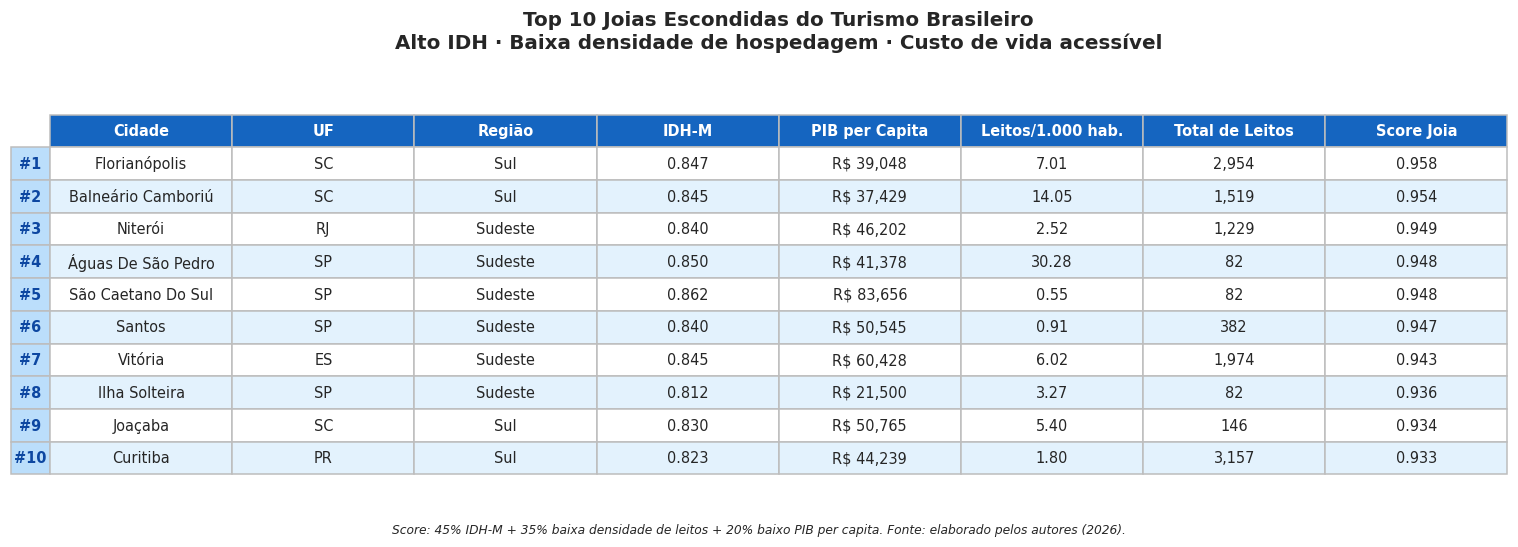

In [ ]:
def _norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

df_j = df.copy()
df_j['_s_idh']    = _norm(df_j['idhm'])
df_j['_s_leitos'] = 1 - _norm(df_j['leitos_1000hab'])
df_j['_s_pib']    = 1 - _norm(df_j['gdp_capita'])
df_j['joia_score'] = 0.45*df_j['_s_idh'] + 0.35*df_j['_s_leitos'] + 0.20*df_j['_s_pib']
df_j = df_j[df_j['beds'] > 0]

top10_j = (
    df_j.nlargest(10, 'joia_score')
    [['city','state','regiao','idhm','gdp_capita','leitos_1000hab','beds','joia_score']]
    .copy()
)
top10_j['gdp_capita']     = top10_j['gdp_capita'].apply(lambda x: f'R$ {x:,.0f}')
top10_j['leitos_1000hab'] = top10_j['leitos_1000hab'].apply(lambda x: f'{x:.2f}')
top10_j['idhm']           = top10_j['idhm'].apply(lambda x: f'{x:.3f}')
top10_j['joia_score']     = top10_j['joia_score'].apply(lambda x: f'{x:.3f}')
top10_j['beds']           = top10_j['beds'].apply(lambda x: f'{int(float(x)):,}')
top10_j.index = range(1, 11)
top10_j = top10_j.rename(columns={
    'city':'Cidade','state':'UF','regiao':'Região','idhm':'IDH-M',
    'gdp_capita':'PIB per Capita','leitos_1000hab':'Leitos/1.000 hab.',
    'beds':'Total de Leitos','joia_score':'Score Joia',
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_axis_off()
tab = ax.table(
    cellText=top10_j.values, colLabels=top10_j.columns,
    rowLabels=[f'#{i}' for i in top10_j.index],
    cellLoc='center', rowLoc='center', loc='center',
)
tab.auto_set_font_size(False)
tab.set_fontsize(9.5)
tab.scale(1, 1.7)

for (row, col), cell in tab.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor('#BBDEFB')
        cell.set_text_props(fontweight='bold', color='#0D47A1')
    else:
        cell.set_facecolor(['#E3F2FD','#FFFFFF'][row % 2])
    cell.set_edgecolor('#BDBDBD')

ax.set_title(
    'Top 10 Joias Escondidas do Turismo Brasileiro\n'
    'Alto IDH · Baixa densidade de hospedagem · Custo de vida acessível',
    fontsize=13, fontweight='bold', pad=16
)
plt.figtext(0.5, 0.01,
    'Score: 45% IDH-M + 35% baixa densidade de leitos + 20% baixo PIB per capita. '
    'Fonte: elaborado pelos autores (2026).',
    ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('g5_tabela_joias_escondidas.png', dpi=150, bbox_inches='tight')
print('Fonte: elaborado pelos autores (2026).')
plt.show()


### 4.11 Mapa do Brasil — Joias Escondidas Destacadas

Fonte: elaborado pelos autores (2026).


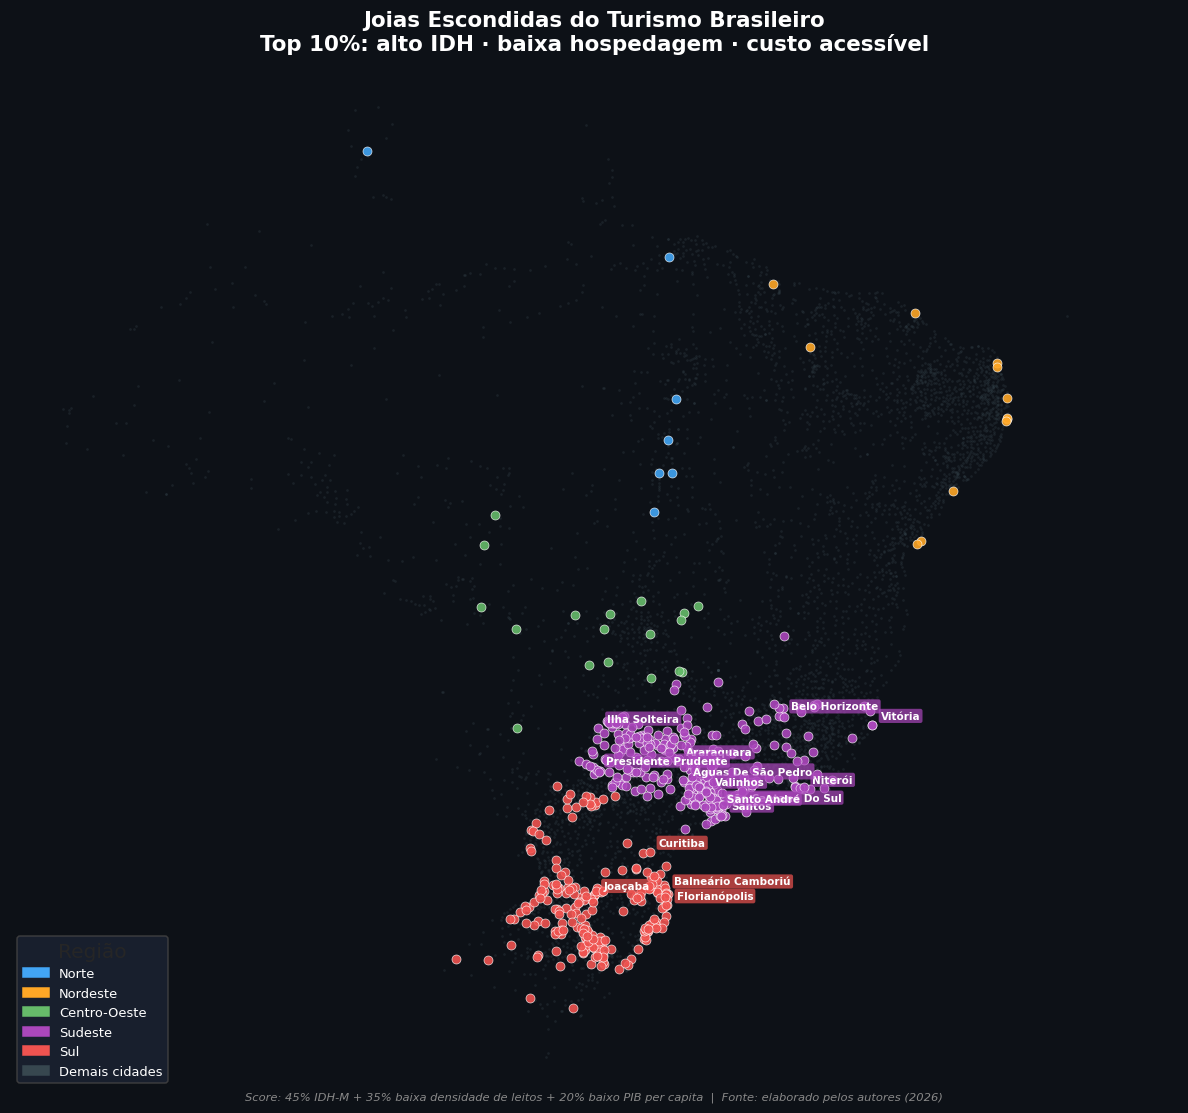

In [ ]:
CORES_REG6 = {
    'Norte':        '#42A5F5',
    'Nordeste':     '#FFA726',
    'Centro-Oeste': '#66BB6A',
    'Sudeste':      '#AB47BC',
    'Sul':          '#EF5350',
}

df_m6 = df.copy()
df_m6['_s_idh']    = (df_m6['idhm'] - df_m6['idhm'].min()) / (df_m6['idhm'].max() - df_m6['idhm'].min() + 1e-9)
df_m6['_s_leitos'] = 1 - (df_m6['leitos_1000hab'] - df_m6['leitos_1000hab'].min()) / (df_m6['leitos_1000hab'].max() - df_m6['leitos_1000hab'].min() + 1e-9)
df_m6['_s_pib']    = 1 - (df_m6['gdp_capita'] - df_m6['gdp_capita'].min()) / (df_m6['gdp_capita'].max() - df_m6['gdp_capita'].min() + 1e-9)
df_m6['joia_score6'] = 0.45*df_m6['_s_idh'] + 0.35*df_m6['_s_leitos'] + 0.20*df_m6['_s_pib']
df_m6 = df_m6[df_m6['beds'] > 0]

THRESH6 = df_m6['joia_score6'].quantile(0.90)
joias6  = df_m6[df_m6['joia_score6'] >= THRESH6].dropna(subset=['lat','long'])
outras6 = df_m6[df_m6['joia_score6'] <  THRESH6].dropna(subset=['lat','long'])

fig, ax = plt.subplots(figsize=(11, 12), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

ax.scatter(outras6['long'], outras6['lat'],
           c='#37474F', s=3, alpha=0.3, linewidths=0, zorder=1)

for regiao, grupo in joias6.groupby('regiao'):
    ax.scatter(grupo['long'], grupo['lat'],
               c=CORES_REG6.get(regiao, '#fff'),
               s=35, alpha=0.9, linewidths=0.4, edgecolors='white',
               zorder=3, label=regiao)

for _, row in joias6.nlargest(15, 'joia_score6').iterrows():
    cor = CORES_REG6.get(row['regiao'], '#fff')
    ax.annotate(row['city'], (row['long'], row['lat']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=6.8, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc=cor, alpha=0.7, ec='none'), zorder=6)

import matplotlib.patches as mpatches
leg6 = [mpatches.Patch(color=c, label=r) for r, c in CORES_REG6.items()]
leg6 += [mpatches.Patch(color='#37474F', label='Demais cidades')]
ax.legend(handles=leg6, title='Região', fontsize=8.5, loc='lower left',
          facecolor='#1c2333', edgecolor='#444', labelcolor='white')

ax.set_xlim(-75, -28)
ax.set_ylim(-35, 6)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title(
    'Joias Escondidas do Turismo Brasileiro\n'
    'Top 10%: alto IDH · baixa hospedagem · custo acessível',
    fontsize=14, fontweight='bold', color='white', pad=14
)
ax.text(0.5, -0.01,
    'Score: 45% IDH-M + 35% baixa densidade de leitos + 20% baixo PIB per capita  |  '
    'Fonte: elaborado pelos autores (2026)',
    transform=ax.transAxes, ha='center', fontsize=7.5, color='#888', style='italic')

plt.tight_layout()
plt.savefig('g6_mapa_joias_escondidas.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Fonte: elaborado pelos autores (2026).')
plt.show()


### 4.11 Comparativo de Procura por Época do Ano
> Curvas de sazonalidade por tipo de destino.

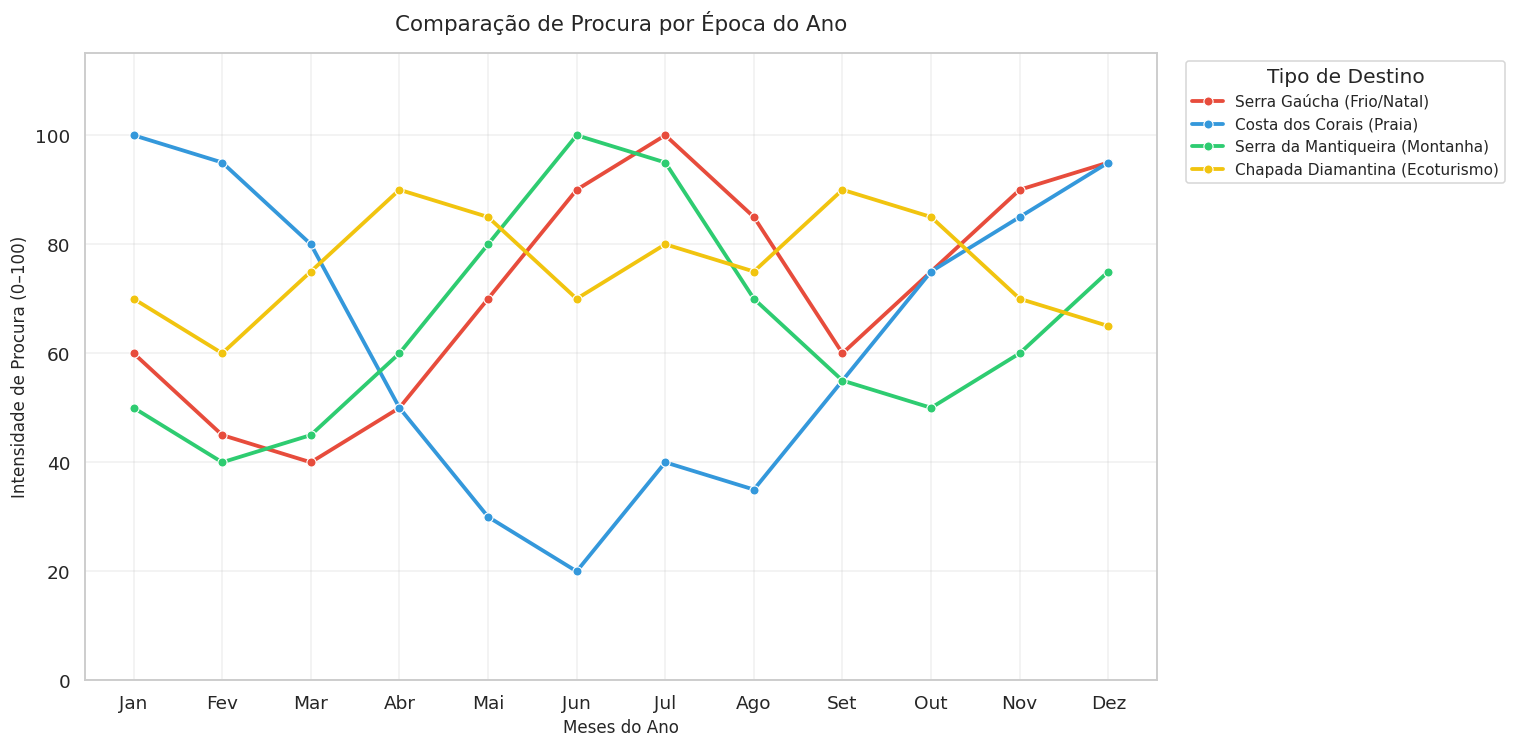

Fonte: elaborado pelos autores (2026).


In [ ]:
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

dados_busca = {
    'Mês': meses,
    'Serra Gaúcha (Frio/Natal)':       [60,45,40,50,70,90,100,85,60,75,90,95],
    'Costa dos Corais (Praia)':         [100,95,80,50,30,20,40,35,55,75,85,95],
    'Serra da Mantiqueira (Montanha)':  [50,40,45,60,80,100,95,70,55,50,60,75],
    'Chapada Diamantina (Ecoturismo)':  [70,60,75,90,85,70,80,75,90,85,70,65],
}
df_busca = pd.DataFrame(dados_busca).melt('Mês', var_name='Região', value_name='Volume de Procura')

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=df_busca, x='Mês', y='Volume de Procura', hue='Região',
             marker='o', linewidth=2.5,
             palette=['#e74c3c','#3498db','#2ecc71','#f1c40f'], ax=ax)
ax.set_title('Comparação de Procura por Época do Ano', fontsize=14, pad=15)
ax.set_ylabel('Intensidade de Procura (0–100)', fontsize=11)
ax.set_xlabel('Meses do Ano', fontsize=11)
ax.set_ylim(0, 115)
ax.grid(alpha=0.3)
ax.legend(title='Tipo de Destino', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('fig_sazonalidade.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

# Insight para o sistema:
# Destinos de praia têm pico no verão; montanha no inverno → recomendação contextual por mês

---
## 📦 Fase 5 — Detecção de Outliers

Valores atípicos podem distorcer análises futuras ou ser casos **extremamente relevantes** para o projeto.
Para cada outlier identificado, avaliamos: *é um erro de dados ou um caso real e especial?*

---
## 💡 Fase 6 — Síntese, Hipóteses e Próximos Passos